# Gravitational Sonar
### Abstract: We present an algorithm -- which, if successful -- would be capable of predicting an approximate spacetime metric for a binary black hole system to within $<1\%$ error of the innermost-stable circular orbit (ISCO). Our algorithm, coined Gravitational Sonar, is valid in the Extreme-Mass Ratio Inspiral (EMRI) limit wherein $m_1>>m_2$. We will validate our algorithm for the Schwarzschild, Kerr, and Johannsen Metrics. We will demonstrate that the algorithm can be employed on LISA waveforms with noise $\sigma>0.05$ to test the No-Hair Theorem and probe for beyond-GR corrections.

# Library Installations

In [1]:
pip install pytearcat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.6 MB/s eta 0:00:00


In [2]:
pip install torch

In [3]:
pip install torchdiffeq

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import math
from torchdiffeq import odeint

In [5]:
import pytearcat as pt

In [6]:
!wget -q https://raw.githubusercontent.com/EliKiani/Optimizing_the_Optimizer_PINNs/main/_optimize.py

In [7]:
!sed -i 's/^from \.\([a-zA-Z_]*\) import/from scipy.optimize.\1 import/' _optimize.py

In [8]:
pip install torch torchdiffeq

In [9]:
pip install xitorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.9/117.9 kB 5.2 MB/s eta 0:00:00


In [10]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs
from scipy.optimize import minimize as minimize_ssbroyden

In [11]:
!grep -n "^def _minimize_bfgs" _optimize.py

1415:def _minimize_bfgs(fun, x0, args=(), jac=None, callback=None,


In [12]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs

from scipy.optimize import minimize  # vanilla dispatcher — now calls the patched BFGS internals

# Import Gravitational Waveforms

We import gravitational waves which were created using a Numerical Kludge orbit-to-waveform mapping forward algorithm (i.e., Quadrupole Approximation + Kerr Geodesics). For a test case, we import just one gravitational wave (technically, there are two polarizations $h_+$ and $h_\times$, so there's two).

Things to test:
- Upgrade from 1 to 3 sets of waveforms, generated by observing the same geodesic from three perspectives (testing the idea of "GPS for Black Holes")
- Since $h_\times \to 0$ as $\theta \to \pi/2$, it may be interesting to try weighting edge-on observers differently than face-on observers to see if it increases the "signal" for numerically smaller components of the Kerr metric
- Not all metric components are created equal: They may not contribute equally to the waveform, so it's important to know which ones contribute the most or least. (Perhaps this would be a so-called "Fisher Analysis" to identify potential sloppy valleys)

θ_obs: pi/4
|h1|_min: tensor(2.3903e-05)
|h1|_max: tensor(1.4579)


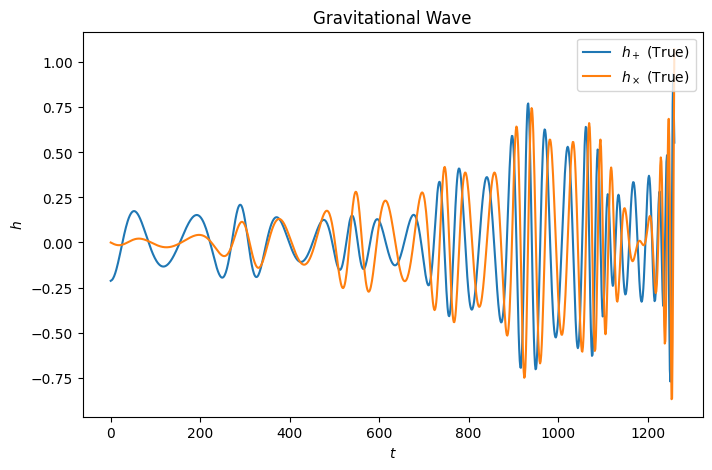

In [13]:
t_true, h_plus_true_obs1 = np.loadtxt('/content/waveform_real_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1260_observertheta_0.7853981633974483.txt', unpack = True)
t_true, h_cross_true_obs1 = np.loadtxt('/content/waveform_imag_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1260_observertheta_0.7853981633974483.txt', unpack = True)
soln_true = np.loadtxt('/content/solution_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1260_observertheta_0.7853981633974483.txt', unpack = True)

h_plus_true_obs1 = torch.tensor(h_plus_true_obs1, dtype = torch.float32)
h_cross_true_obs1 = torch.tensor(h_cross_true_obs1, dtype = torch.float32)

print("θ_obs: pi/4")
print("|h1|_min:", min(h_plus_true_obs1**2 + h_cross_true_obs1**2))
print("|h1|_max:", max(h_plus_true_obs1**2 + h_cross_true_obs1**2))

fig, ax = plt.subplots(figsize=(8,5))
plt.plot(t_true, h_plus_true_obs1, label = r"$h_+$ (True)")
plt.plot(t_true, h_cross_true_obs1, label = r"$h_\times$ (True)")
plt.legend(loc = "upper right")
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.title('Gravitational Wave')
plt.show()

# Input Parameters

The neural network is supplied with the exact orbital parameters (and thus, supplied with the correct initial conditions).

Things to test:
- Approach 1: A curriculum-based approach where one chops up the waveform into many pieces and iteratively trains on larger sections of the waveform (i.e., increase `t_test` from `[:600]` to `[:1200]` to `[:2000]`)
- Approach 2: Train on the entire waveform from the start, but iteratively sample the waveform with more points (i.e., increase `t_test` from `[::40]` to `[::100]` to `[::500]`)

In [14]:
rp_true = 10
ra_true = 14
a_true = 0.9
θmin_true = math.pi/4
θ_observed = [math.pi/4]

In [15]:
t = torch.linspace(0, 1260, 1000)
t_final = 1260
t_test = t[:t_final]

print(len(t))
print(len(t_test))

1000
1000


In [16]:
h_plus_true = [h_plus_true_obs1[:t_final]]
h_cross_true = [h_cross_true_obs1[:t_final]]

# Neural Network

Build the neural network to be extremely small and simple (for starters).

Things to test:
- Increase neural network dimensions (although historically, this should be a last resort)
- Try different network architechtures (i.e., hourglass)
- Try different activation functions (i.e., ReLU, SiLU, etc.)
- Try different neural network inputs (i.e., [log(r), Θ] instead of [r, Θ])

In [17]:
import torch

class NN_Metric(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = torch.nn.Linear(2, 8) # 2 inputs -> 8 hidden features
    self.act = torch.nn.SiLU()       # non-linear hidden transform
    self.fc2 = torch.nn.Linear(8, 5) # 8 hidden features -> 5 metric fields

  def forward(self, x):
    hidden = self.act(self.fc1(x))
    return self.fc2(hidden)

In [18]:
def nn_input(r, θ):
  return torch.stack([
      1/r,
      torch.cos(θ).square()
  ])

In [19]:
torch.manual_seed(0)
net = NN_Metric()
x = torch.tensor([2.0, 1.57])
out = net(x)
print(out)

tensor([-0.0663, -0.2923, -0.1640,  0.0423,  0.4105], grad_fn=<ViewBackward0>)


In [20]:
def Kerr(x, a, M=1):
  zero = torch.tensor(0.)
  r = x[1]
  θ = x[2]
  Δ = r**2 - 2*M*r + a**2
  Σ = r**2 + a**2 * (torch.cos(θ))**2
  A = (r**2 + a**2)**2 - Δ * a**2 * (torch.sin(θ))**2
  g_tt = -(1-2*M*r/Σ)
  g_rr = Σ/Δ
  g_θθ = Σ
  g_ϕϕ = A/Σ * (torch.sin(θ))**2
  g_tϕ = (-2*M*r/Σ) * a * (torch.sin(θ))**2
  row1 = torch.stack([g_tt, zero, zero, g_tϕ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tϕ, zero, zero, g_ϕϕ])
  kerr = torch.stack([row1, row2, row3, row4])
  return kerr

def g_Kerr(r, θ, M=1.0, a=a_true):

  Σ = lambda r, θ: r**2 + (a**2)*(torch.cos(θ))**2
  Δ = lambda r, θ: r**2 - 2*M*r + a**2
  A = (r**2 + a**2)**2 - Δ(r, θ) * a**2 * (torch.sin(θ))**2

  g_tt = - (1 - 2*M*r / Σ(r, θ))
  g_rr = Σ(r, θ) / Δ(r, θ)
  g_θθ = Σ(r, θ)
  g_φφ = A / Σ(r, θ) * (torch.sin(θ))**2
  g_tφ = - (2*M*r / Σ(r, θ)) * a * (torch.sin(θ))**2

  zero = torch.tensor(0.)
  row1 = torch.stack([g_tt, zero, zero, g_tφ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tφ, zero, zero, g_φφ])
  return torch.stack([row1, row2, row3, row4])

# Ansatz

This ansatz was designed very carefully with a two-scale approach in mind:
- The ansatz must approach the correct far-field Minkowski flat spacetime limit as $r\to ∞$
- The ansatz should respect any poles or be able to represent any divergences or blow-ups in metric components as $r\to r_+$ (Outer Event Horizon of Kerr). Examples: $g_{tt}=0$ is the Ergosphere, $g^{rr}=0$ is the Event Horizon, $g_{\theta\theta}=0$ is the Singularity, and $-g_{t\phi}/g_{\phi\phi}=\omega$
- As $r\to r_+$ during the inspiral, frame-dragging should cause the second, smaller black hole to orbit the central black hole at $\Omega \to \Omega_H$, the horizon's own angular spin rate. This should be reflected in the gravitational wave frequency, which is twice that of the orbital frequency. Thus, the gravitational wave frequency at the peak amplitude should directly tell us the size of the event horizon for the massive, central black hole. I believe that this deduction holds only for EMRIs (Extreme-Mass Ratio Inspirals), where the smaller, secondary black hole can be treated as a particle on a geodesic around the larger black hole.
- The ansatz is inspired by a post-newtonian expansion, with the 0th-order $O(g^0)$ term being flat, Minkowski spacetime; the 1st-order term $O(g^1)$ is Schwarzschild spacetime; the 2nd-order term $O(g^2)$ is Kerr spacetime; the 3rd-order term $O(g^3)$ or beyond would be corrections to Kerr or beyond-GR, ideally, although the ansatz does not have this yet perhaps.
- Try using `ln(r)` as an input for the neural network?

In [21]:
import torch.nn.functional as F

def NN_Ansatz(r, θ, NN):
  u = 1 / r

  g_tt = -1 + u * NN[0]
  g_rr_inv = 1 + u * NN[1]
  g_rr = 1 / g_rr_inv
  g_θθ = r**2 + NN[2]
  g_φφ = torch.sin(θ)**2 * (r**2 + NN[3])
  g_tφ = u * torch.sin(θ)**2 * NN[4]

  zero = torch.tensor(0.)
  row1 = torch.stack([g_tt, zero, zero, g_tφ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tφ, zero, zero, g_φφ])
  return torch.stack([row1, row2, row3, row4])

In [22]:
GTPHI_ALPHA = None
WHOLE_METRIC_ALPHA = None

def metric_from_network(network, r, θ, params_dict=None):
    inputs = nn_input(r, θ)

    if params_dict is None:
        fields = network(inputs)
    else:
        fields = torch.func.functional_call(
            network,
            params_dict,
            (inputs,),
        )

    metric = NN_Ansatz(r, θ, fields)

    # Diagnostic only: interpolate the entire covariant metric.
    if WHOLE_METRIC_ALPHA is not None:
        kerr_metric = g_Kerr(
            r,
            θ,
            M=1.0,
            a=a_true,
        ).to(
            dtype=metric.dtype,
            device=metric.device,
        )

        alpha = torch.as_tensor(
            WHOLE_METRIC_ALPHA,
            dtype=metric.dtype,
            device=metric.device,
        )

        return (
            (1.0 - alpha) * metric
            + alpha * kerr_metric
        )

    # Existing one-component diagnostic follows.
    if GTPHI_ALPHA is None:
        return metric

    Σ = r**2 + a_true**2 * torch.cos(θ)**2
    kerr_gtφ = (
        -2
        * r
        * a_true
        * torch.sin(θ)**2
        / Σ
    )

    blended_gtφ = (
        (1 - GTPHI_ALPHA) * metric[0, 3]
        + GTPHI_ALPHA * kerr_gtφ
    )

    row1 = torch.stack([
        metric[0, 0],
        metric[0, 1],
        metric[0, 2],
        blended_gtφ,
    ])

    row4 = torch.stack([
        blended_gtφ,
        metric[3, 1],
        metric[3, 2],
        metric[3, 3],
    ])

    return torch.stack([
        row1,
        metric[1],
        metric[2],
        row4,
    ])

# Hamiltonian

The Hamiltonian is constructed from a given metric as $H=\frac{1}{2}*p_\mu*g^{\mu\nu}*p_\nu$. I have now included a very simple dissipation term.

Things to test:
- For the initial test, dissipation will be baked in! The neural network will not be asked to predict it. Its only job will be to predict the kerr metric by making the right predictions for its 10 outputs.
- If the first preliminary test succeeds, where the network is able to predict the kerr metric (with dissipation baked in), then I will upgrade the dissipation term to be more realistic, reflecting post-newtonian $\dot \phi \propto r^{-7/2}$ dissipation
- If that test also succeeds, then I'll create a separate neural network `NN_Dissipative` which attempts to predict the dissipation whilst `NN_Conservative` predicts the entire kerr metric

In [23]:
def H_function(state, network, params_dict):
  x = state

  def H(state):
    t, r, θ, φ, p_t, p_r, p_θ, p_φ = state
    g = metric_from_network(network, r, θ, params_dict)
    inv_g = torch.linalg.inv(g)

    p = torch.stack([p_t, p_r, p_θ, p_φ])
    H = 0.5 * p @ inv_g @ p
    return H

  grad_H = torch.func.grad(H)(x)

  I4 = torch.eye(4)
  Z4 = torch.zeros(4,4)
  J = torch.cat([
      torch.cat([Z4, I4], 1),
      torch.cat([-I4, Z4], 1)
  ])

  Conservative = J @ grad_H
  Dissipative = (-10e-4) * torch.tensor([0, 0, 0, 0, 0, 0, 0, 1])

  du_dτ = Conservative + Dissipative

  dH_dpₜ = grad_H[4]
  dτ_dt = (dH_dpₜ)**(-1)

  du = du_dτ * dτ_dt
  du[0] = 1

  return du


# Quadrupole Approximation

In [24]:
def d2_dt2(v, dt):
    # uses second-order one-sided difference stencils at the endpoints; see https://doi.org/10.1090/S0025-5718-1988-0935077-0
    a = 2*v[0] - 5*v[1] + 4*v[2] - v[3]
    b = v[:-2] - 2*v[1:-1] + v[2:]
    c = 2*v[-1] - 5*v[-2] + 4*v[-3] - v[-4]

    return torch.cat([a.reshape(1), b, c.reshape(1)])/(dt**2)

def Soln2Orbit(soln, t, a):
  r = soln[:, 1]
  θ = soln[:, 2]
  ϕ = soln[:, 3]

  x, y, z = BoyerLindquist2Cartesian(r, θ, ϕ, a = a)
  orbit = torch.stack([x, y, z])

  return orbit

def BoyerLindquist2Cartesian(r, θ, ϕ, a):

  x = r * torch.sin(θ) * torch.cos(ϕ)
  y = r * torch.sin(θ) * torch.sin(ϕ)
  z = r * torch.cos(θ)

  return x, y, z

def Q_ij(orbit, t, μ = 1.0):
  N = orbit.shape[1]
  Q = torch.zeros(3, 3, N)

  for i in range(3):
    for j in range(3):
      for k in range(N):
        δij = 1.0 if i==j else 0.0
        x = orbit[:, k]
        r2 = torch.sum(x**2)
        Q[i, j, k] = μ * (x[i] * x[j] - (1/3) * δij * r2)
  return Q

def Q_ddot(Q, dt):
  Qdd = torch.zeros_like(Q)

  for i in range(3):
    for j in range(3):
      Qdd[i, j, :] = d2_dt2(Q[i, j, :], dt)

  return Qdd

In [25]:
def assert_uniform_time(t, rtol = 1e-3):
  dt = t[1] - t[0]
  assert torch.all(torch.abs(torch.diff(t) - dt) < rtol * torch.abs(dt)), "t must be uniformly sampled in coordinate time!"
  return dt

def Observer_Basis(θ_obs, ϕ_obs):
  n = [
      torch.sin(θ_obs) * torch.cos(ϕ_obs),
      torch.sin(θ_obs) * torch.sin(ϕ_obs),
      torch.cos(θ_obs)
  ]

  p = [
      torch.cos(θ_obs) * torch.cos(ϕ_obs),
      torch.cos(θ_obs) * torch.sin(ϕ_obs),
    - torch.sin(θ_obs)
  ]

  q = [
    - torch.sin(ϕ_obs),
      torch.cos(ϕ_obs),
      0.0
  ]

  return n, p, q

Observer_Basis(torch.tensor(0.0), torch.tensor(0.0))

def h(Qdd, θ_obs = 0.0, ϕ_obs = 0.0, D = 1.0):
  n, p, q = Observer_Basis(torch.tensor(θ_obs), torch.tensor(ϕ_obs))
  N = Qdd.shape[2]

  h_plus = torch.zeros(N)
  h_cross = torch.zeros(N)

  for k in range(N):
    h_plus_k = 0
    h_cross_k = 0
    for i in range(3):
      for j in range(3):

        e_plus = p[i] * p[j] - q[i] * q[j]
        e_cross = p[i] * q[j] + q[i] * p[j]

        h_plus_k += (1/D) * e_plus * Qdd[i, j, k]
        h_cross_k += (1/D) * e_cross * Qdd[i, j, k]

    h_plus[k] = h_plus_k
    h_cross[k] = h_cross_k

  return h_plus, h_cross

In [26]:
def create_gravityWave(t, soln, a, μ = 1.0, θ_obs = 0.0, ϕ_obs = 0.0, D = 1.0):
  orbit = Soln2Orbit(soln, t, a = a)
  dt = assert_uniform_time(t)
  Q = Q_ij(orbit, t, μ = μ)
  Qdd = Q_ddot(Q, dt)
  h_plus, h_cross = h(Qdd, θ_obs = θ_obs, ϕ_obs = ϕ_obs, D = D)

  return h_plus, h_cross

# Initial Conditions

In [27]:
from scipy import optimize

a_true = 0.9

def solve_ELQ(rₚ, rₐ, θmin, M = 1.0, a = a_true, μ = 1.0):
    Δₚ = rₚ**2 - 2*M*rₚ + a**2
    Δₐ = rₐ**2 - 2*M*rₐ + a**2

    def equations(x):
        E, Lz = x[0], x[1]
        Q_from_rₚ = (((rₚ**2 + a**2) * E - a * Lz)**2 - Δₚ * ((Lz-a*E)**2 + μ**2 * rₚ**2) ) / Δₚ

        F0 = ((rₐ**2 + a**2) * E - a * Lz)**2 - Δₐ * ( (Lz - a*E)**2 + μ**2 * rₐ**2 + Q_from_rₚ )
        F1 = Q_from_rₚ - math.cos(θmin)**2 * (a**2 * (μ**2 - E**2) + Lz**2 / math.sin(θmin)**2 )
        return [F0, F1]

    # Initial Guesses
    E0 = math.sqrt( 1 - 2 * M / (rₚ + rₐ) )
    L0 = math.sqrt( M * (rₚ + rₐ) / 2 )
    sol = optimize.fsolve(equations, [E0, L0])

    E, Lz = sol
    Δₚ_val = rₚ**2 - 2*M*rₚ + a**2
    Q = ( ((rₚ**2 + a**2) * E - a * Lz)**2 - Δₚ_val *  ( (Lz - a*E)**2 + μ**2 * rₚ**2 ) ) / Δₚ_val

    return E, Lz, Q

def make_u0(rₚ, rₐ, θmin, M = 1.0, a = a_true, μ = 1.0):
    E, Lz, Q = solve_ELQ(rₚ, rₐ, θmin, M = M, a = a, μ = μ)
    return torch.tensor([0.0, rₚ, θmin, 0.0,
            -E, 0.0, 0.0, Lz], dtype = torch.get_default_dtype())

# RK4 Integration

In [28]:
def RK4(f, t, y, h):
  k1 = f(t, y)
  k2 = f(t + h/2, y + h/2 * k1)
  k3 = f(t + h/2, y + h/2 * k2)
  k4 = f(t + h, y + h * k3)
  y_next = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
  return y_next

def integrate(f, y0, t_array):
  h = t_array[1]-t_array[0]
  states = [y0]

  for i in range(len(t_array)-1):
    next_state = RK4(f, t_array[i], states[i], h)
    states.append(next_state)

  return torch.stack(states)

# Waveform Loss Term

In [29]:
def waveform_loss(network, eps = 1e-12):
  params_dict = dict(network.named_parameters())
  dyn = lambda t, state: H_function(state, network, params_dict)

  h_plus_pred = []
  h_cross_pred = []

  u0 = make_u0(rp_true, ra_true, θmin_true)
  predicted_geodesic = integrate(dyn, u0, t_test)

  waveformLoss = torch.zeros((), dtype=t_test.dtype, device=t_test.device)
  num_waveforms = len(θ_observed)

  for i in range(num_waveforms):
    pred_h_plus, pred_h_cross = create_gravityWave(t_test, predicted_geodesic, a_true, θ_obs = θ_observed[i], ϕ_obs = 0.0)
    h_plus_pred.append(pred_h_plus)
    h_cross_pred.append(pred_h_cross)

    squared_error = ( (h_plus_pred[i]-h_plus_true[i]).square()
                  + (h_cross_pred[i]-h_cross_true[i]).square() ).mean()

    truth_power = (
        h_plus_true[i].square() + h_cross_true[i].square()
    ).mean().detach()

    waveformLoss += squared_error / (truth_power + eps)

  waveformLoss /= num_waveforms
  return waveformLoss, h_plus_pred, h_cross_pred

## Waveform Gate: Reproducing the Kerr $h(t)$

In [30]:
def H_Kerr(state):
  def H(state):
    q = state[:4]
    p = state[4:]
    g = Kerr(q, a = a_true)
    inv_g = torch.linalg.inv(g)

    H = 0.5 * p @ inv_g @ p
    return H

  grad_H = torch.func.grad(H)(state)

  I4 = torch.eye(4)
  Z4 = torch.zeros(4,4)
  J = torch.cat([
      torch.cat([Z4, I4], 1),
      torch.cat([-I4, Z4], 1)
  ])

  Conservative = J @ grad_H
  Dissipative = (-10e-4) * torch.tensor([0, 0, 0, 0, 0, 0, 0, 1])

  du_dτ = Conservative + Dissipative

  dH_dpₜ = grad_H[4]
  dτ_dt = (dH_dpₜ)**(-1)

  du = du_dτ * dτ_dt
  du[0] = 1

  return du


In [31]:
u0_gate = make_u0(
    rp_true, ra_true, θmin_true,
    a=a_true
)

dyn_gate = lambda time, state: H_Kerr(state)

trajectory_gate = integrate(
    dyn_gate, u0_gate, t_test
)

h_plus_gate, h_cross_gate = create_gravityWave(
    t_test,
    trajectory_gate,
    a_true,
    θ_obs = θ_observed[0],
    ϕ_obs = 0.0
)

h_plus_reference = h_plus_true[0]
h_cross_reference = h_cross_true[0]

In [32]:
h_gate = torch.complex(h_plus_gate, h_cross_gate)
h_reference = torch.complex(h_plus_reference, h_cross_reference)

relative_L2 = (
    100 * torch.linalg.vector_norm(h_gate - h_reference)
    / (torch.linalg.vector_norm(h_reference) + 1e-12)
)

print("L2 Error (θ=π/4):", relative_L2.item())

L2 Error (θ=π/4): 0.3428505063056946


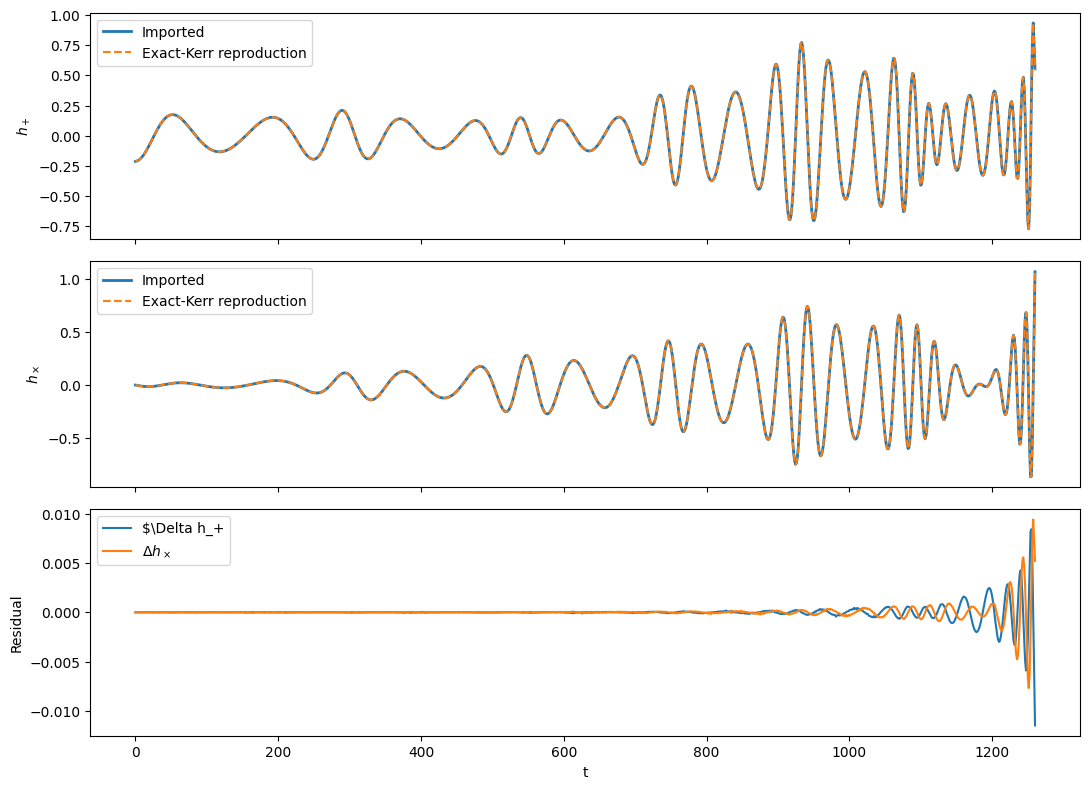

In [33]:
fig, ax = plt.subplots(3, 1, figsize = (11,8), sharex=True)

ax[0].plot(t_test, h_plus_reference, label = "Imported", linewidth=2)
ax[0].plot(t_test, h_plus_gate.detach(), "--", label = "Exact-Kerr reproduction")
ax[0].set_ylabel(r"$h_+$")
ax[0].legend()

ax[1].plot(t_test, h_cross_reference, label = "Imported", linewidth = 2)
ax[1].plot(t_test, h_cross_gate.detach(), "--", label = "Exact-Kerr reproduction")
ax[1].set_ylabel(r"$h_\times$")
ax[1].legend()

ax[2].plot(t_test, (h_plus_gate - h_plus_reference).detach(), label = r"$\Delta h_+")
ax[2].plot(t_test, (h_cross_gate-h_cross_reference).detach(), label = r"$\Delta h_\times$")
ax[2].set_xlabel("t")
ax[2].set_ylabel("Residual")
ax[2].legend()

plt.tight_layout()

# Ricci Loss Term

## Ricci Loss Term Components

In [34]:
def christ_awful(metric, x):
  partial_g = torch.func.jacfwd(metric)(x)
  ginv = torch.linalg.inv(metric(x))
  term1 = torch.einsum("ms, sab->mab", ginv, partial_g)
  term2 = torch.einsum("ms, sba->mab", ginv, partial_g)
  term3 = torch.einsum("ms, abs->mab", ginv, partial_g)
  christoffel = 0.5 * (term1 + term2 - term3)
  return christoffel

In [35]:
def Riemann(metric, x):
  dGamma = torch.func.jacfwd(christ_awful, argnums=1)(metric, x)
  term1 = torch.einsum("abvu->abuv", dGamma)
  term2 = torch.einsum("abuv->abuv", dGamma)
  term3 = torch.einsum("aup,pbv->abuv", christ_awful(metric, x), christ_awful(metric, x))
  term4 = torch.einsum("avp,pbu->abuv", christ_awful(metric, x), christ_awful(metric, x))
  Riemann = term1 - term2 + term3 - term4
  return Riemann

In [36]:
def Ricci(metric, x):
  ricci = torch.einsum("abav->bv", Riemann(metric, x))
  return ricci

## Gate: Test on Exact Schwarzschild & Kerr Metrics

In [37]:
def Schwarzschild(x, M=1):
  zero = torch.tensor(0.)
  r = x[1]
  θ = x[2]
  g_tt = -(1-2*M/r)
  g_rr = (1-2*M/r)**(-1)
  g_θθ = r**2
  g_ϕϕ = r**2 * (torch.sin(θ))**2
  row1 = torch.stack([g_tt, zero, zero, zero])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([zero, zero, zero, g_ϕϕ])
  schild = torch.stack([row1, row2, row3, row4])
  return schild

In [38]:
x = torch.tensor([0.0, 10.0, math.pi/2, 0.0])
input_spin = torch.tensor(0.9, dtype = x.dtype)
kerr_gate = lambda x: Kerr(x, a=input_spin)
schwarzschild_gate = lambda x: Schwarzschild(x)
print("Kerr Gate:", Ricci(kerr_gate, x))
print("\nSchwarzschild Gate:", Ricci(schwarzschild_gate, x))

Kerr Gate: tensor([[ 3.4925e-10,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  2.3283e-09, -3.3654e-16,  0.0000e+00],
        [ 0.0000e+00,  1.1484e-15,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.7881e-07]])

Schwarzschild Gate: tensor([[-1.1642e-10,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  2.3283e-09,  8.8818e-16,  0.0000e+00],
        [ 0.0000e+00,  8.8818e-16,  1.4901e-08,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.4901e-08]])


# Frequency Loss Term

## $L(\tilde{h}_{pred}, \tilde{h}_{true})$

In [39]:
def SpectralLoss(h_true, h_pred):
    """
    Measures mean relative squared FFT-magnitude error.
    Ensures the network hears the 'ISCO Cliff' and 'Inspiral Slope' equally [1].
    """
    N = h_true.size(0)
    # Ensure window is on the same device as the data
    hann_window = torch.hann_window(N, periodic=True).to(h_true.device)

    # Apply window to prevent edge-effect frequency leakage
    h_true_fft = torch.fft.fft(hann_window * h_true)
    h_pred_fft = torch.fft.fft(hann_window * h_pred)

    # Use log-scale to handle the orders of magnitude in the FrequencyGW profile [1]
    h_true_mag = torch.abs(h_true_fft)
    h_pred_mag = torch.abs(h_pred_fft)

    eps = 1e-4 * h_true_mag.pow(2).mean()

    num = (h_true_mag - h_pred_mag).pow(2)
    spec_loss = num / (h_true_mag.pow(2) + eps)
    spec_loss_avg = spec_loss.mean()

    spec_loss = spec_loss_avg
    return spec_loss

## Gate: $L_{\omega}(h_{true},h_{true})=0$

In [40]:
# Gate: SpectralLoss(h_true, h_true) should be 0
test_h = torch.complex(h_plus_true_obs1, h_cross_true_obs1)
gate_val = SpectralLoss(test_h, test_h)
print(gate_val)

tensor(0.)


## Gate: Kerr Circular, Equatorial Frequency $\Omega=\frac{M^{1/2}}{r^{3/2}+aM^{1/2}}$

In [41]:
def AnalyticFrequencyGate(r_val=10.0, a_spin=0.9, M=1.0):
    """
    SpaceX-style pre-flight check: Tests the SpectralLoss against the
    theoretical Kerr frequency Ω = sqrt(M) / (r^1.5 + a*sqrt(M)).
    """
    # 1. Calculate analytic GW frequency (ω = 2 * Ω) [1]
    omega_orbit = math.sqrt(M) / (r_val**1.5 + a_spin * math.sqrt(M))
    omega_gw = 2 * omega_orbit

    # 2. Create synthetic pure-tone signal (exp(i * omega * t))
    # Using the same time array as your training window (e.g., 1000 samples)
    t_gate = t.detach().clone()
    h_analytic = torch.complex(torch.cos(omega_gw * t_gate),
                               torch.sin(omega_gw * t_gate))

    # 3. Test 1: Self-consistency (Perfect match should be ~0)
    loss_self = SpectralLoss(h_analytic, h_analytic)

    # 4. Test 2: Frequency Sensitivity (Shift frequency by 1% to test 'ears')
    h_shifted = torch.complex(torch.cos(1.01 * omega_gw * t_gate),
                              torch.sin(1.01 * omega_gw * t_gate))
    loss_shifted = SpectralLoss(h_analytic, h_shifted)

    print(f"--- Analytic Frequency Gate (r={r_val}, a={a_spin}) ---")
    print(f"Theoretical ω_GW: {omega_gw:.6f}")
    print(f"Gate Self-Loss:   {loss_self.item():.2e} (Success if ~0)")
    print(f"Gate Shift-Loss:  {loss_shifted.item():.2e} (Success if > 0)")

    return loss_self, loss_shifted

# Run before launching the Golden Run
AnalyticFrequencyGate(r_val=10.0, a_spin=a_true)

--- Analytic Frequency Gate (r=10.0, a=0.9) ---
Theoretical ω_GW: 0.061495
Gate Self-Loss:   0.00e+00 (Success if ~0)
Gate Shift-Loss:  8.16e-04 (Success if > 0)


(tensor(0.), tensor(0.0008))

## Frequency Loss Plot

In [42]:
def plotSpectralDiagnostic(h_true, h_pred, dt=1.0):
    """
    Visualizes the spectral 'DNA' match between True and Predicted signals.
    Mirrors the 'FrequencyGW' log-log profile [120, user history].
    """
    N = h_true.size(0)
    hann_window = torch.hann_window(N, periodic=True).to(h_true.device)

    # Compute FFTs of windowed signals [user history]
    f_true = torch.fft.fft(hann_window * h_true)
    f_pred = torch.fft.fft(hann_window * h_pred)

    freqs = torch.fft.fftfreq(N, d=dt, device=h_true.device)
    positive = freqs > 0

    # Frequency axis in Hz (assuming dt from your create_gravityWave function) [2]
    freqs = freqs[positive].detach().cpu()


    # Magnitudes [1]
    mag_true = torch.abs(f_true[positive]).detach().cpu()
    mag_pred = torch.abs(f_pred[positive]).detach().cpu()

    plt.figure(figsize=(10, 6))
    plt.loglog(freqs, mag_true, 'r-', label='True (Analytical)', linewidth=2)
    plt.loglog(freqs, mag_pred, 'g--', label='Predicted (Network)', linewidth=2)

    plt.title("Spectral Magnitude Profile: $|\tilde{h}(f)|$ vs $f$")
    plt.xlabel("Frequency $f$ [Hz]")
    plt.ylabel("Magnitude $|\tilde{h}(f)|$")
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.show()

# Boundary Condition Loss Term

## 4 Tricks: Square, Normalize, Exponentiate, and Weight

In [43]:
import torch

def resid(metric, x):
    g_rr = metric(x)[1,1]
    g_rr_inv = 1/g_rr
    return g_rr_inv

def boundaryConditionLoss(metric):
  M = 1
  zero = torch.tensor(0.)
  r_vals = torch.linspace(1*M, 2.01*M, 80)
  θ_vals = torch.linspace(0, math.pi/2, 4)
  tau = 1e-4

  roots = []
  root_residuals = [] # g^{rr}(r_H, θ)^2 -- penalizes "no real zero here"
  sign_penalties = []


  for θ in θ_vals:
    badness_vals = []
    for r in r_vals:
      x = torch.stack([zero, r, θ, zero])
      badness = resid(metric, x)**2 # square it
      badness_vals.append(badness) # add it to the array

    weights = torch.softmax(-torch.stack(badness_vals)/tau, dim=0)
    weighted_average = (weights * r_vals).sum()
    roots.append(weighted_average)

    x_root = torch.stack([zero, weighted_average, θ, zero])
    root_residuals.append(resid(metric, x_root)**2)

    x_lo = torch.stack([zero, r_vals[0], θ, zero])
    x_hi = torch.stack([zero, r_vals[-1], θ, zero])
    sign_penalties.append(F.relu(resid(metric, x_lo) * resid(metric, x_hi))) # >0 only if same-sign (no crossing)

  location_consistency = torch.var(torch.stack(roots))
  zero_crossing_penalty = torch.stack(root_residuals).mean()
  sign_change_penalty = torch.stack(sign_penalties).mean()

  L2_norm_BC_loss = location_consistency + zero_crossing_penalty + sign_change_penalty

  return L2_norm_BC_loss, roots

## Gate: Kerr $a=0, r_H=1.43M$

In [44]:
metric_fn = lambda x: Kerr(x, a = 0.9)
boundaryConditionLoss(metric_fn)

(tensor(4.6474e-08),
 [tensor(1.4356), tensor(1.4358), tensor(1.4360), tensor(1.4361)])

## Gate: Schwarzschild $a=0, r_H=2M$

In [45]:
metric_fn = lambda x: Kerr(x, a = 0)
boundaryConditionLoss(metric_fn)

(tensor(2.3338e-06),
 [tensor(1.9969), tensor(1.9969), tensor(1.9969), tensor(1.9969)])

# Loss Function

Things to test:
- Exponential ricci grid sampling (i.e., `r_grid = 1 +. 10^([-3, 3, 10])`) so that near-Horizon is sampled more strongly than far-away
- A very good training log required to log / print out the weights of each loss term as they change, the predicted metric as it evolves during training, etc.

In [46]:
π = math.pi

P_WAVEFORM = 1.0
P_RICCI = 0.5
P_FREQUENCY = 0.1
P_BC = 0.1

def loss(network):
  # --------- RICCI LOSS ---------------
  r_inner = torch.logspace(
      math.log10(2.0),
      math.log10(20.0),
      steps = 20,
  )

  r_outer = torch.tensor(
      [30.0, 50.0, 100.0, 200.0],
      dtype = r_inner.dtype,
      device = r_inner.device
  )

  r_grid = torch.cat([r_inner, r_outer])
  θ_grid = torch.linspace(π/20, π/2, 4)

  def g(x):
    return metric_from_network(network, x[1], x[2])

  ricci_sum = torch.zeros(())
  ricci_count = 0

  for r in r_grid:
    for θ in θ_grid:
      zero = torch.tensor(0.)
      x = torch.stack([zero, r, θ, zero])
      ricci_sum += Ricci(g, x).pow(2).sum()
      ricci_count += 1

  ricciLoss = ricci_sum / ricci_count

  # --------- WAVEFORM LOSS ---------------
  waveformLoss, pred_h_real, pred_h_imag = waveform_loss(network)
  h_pred_complex = torch.complex(pred_h_real[0], pred_h_imag[0])
  h_true_complex = torch.complex(h_plus_true[0], h_cross_true[0])

  # --------- BOUNDARY LOSS ---------------
  boundaryCondition_Loss, roots = boundaryConditionLoss(g)

  # --------- FREQUENCY LOSS ---------------
  freq_Loss = SpectralLoss(h_true_complex, h_pred_complex)

  # --------- TOTAL LOSS ---------------
  total_loss = (P_WAVEFORM * waveformLoss
              + P_RICCI * ricciLoss
              + P_FREQUENCY * freq_Loss
              + P_BC * boundaryCondition_Loss)

  return (total_loss, waveformLoss,
          ricciLoss, freq_Loss,
          boundaryCondition_Loss, roots)

# Checkpoints

In [47]:
import os
from google.colab import drive
drive.mount("/content/drive")

CHECKPOINT_PATH = "/content/drive/MyDrive/sonar_v15_live.pt"
FINAL_PATH = "/content/drive/MyDrive/sonar_v15_final.pt"
RESUME = False

def save_checkpoint(stride_idx, epoch, n, loss_history):
  torch.save({
      "net_state": net.state_dict(),
      "stride_idx": stride_idx,
      "epoch": epoch,
      "n": n,
      "loss_history": loss_history,
  }, CHECKPOINT_PATH)

def load_checkpoint():
  if not os.path.exists(CHECKPOINT_PATH):
    return None
  return torch.load(CHECKPOINT_PATH)

Mounted at /content/drive


# Diagnostics Log

In [48]:
from prettytable import PrettyTable
import time

def rel_L2_error(pred, true, eps = 1e-12):
  return 100 * torch.sqrt(
                          torch.sum((pred - true) ** 2) / (torch.sum((true) ** 2) + eps)
                         )

# -------- Psuedo-code structure --------
# for each radius:
  # evaluate predicted metric at each \theta on a grid [π/20, π/4, π/3, π/2]
  # stack the \theta-profile of the metrics into a tensor of shape [n_theta, 4, 4]
  # compute L2 error for each metric component (i.e., g_tt, g_rr, etc.) across all theta values via L2(g_pred[:, \mu, \nu], g_true[:, \mu, \nu])
  # add that relative angular-profile error at a given radius for a given metric component as a row to the diagnostics table

def log_diagnostics(
    network, total_loss,
    w, r, f, b, roots, n,
    elapsed_time
  ):

  r_grid = [2, 3, 4, 5, 6, 12, 20] # Use these explicit r values
  θ_grid = [π/20, π/4, π/3, π/2] # Use these explicit θ values

  gtt_error_vals = []
  grr_error_vals = []
  gθθ_error_vals = []
  gϕϕ_error_vals = []
  gtϕ_error_vals = []
  ricci_error_vals = []

  param = next(network.parameters())

  for r_val in r_grid:
    pred_vec = []
    true_vec = []
    ricci_at_radius = []

    for θ in θ_grid:
      r_t = torch.tensor(r_val, dtype = param.dtype, device = param.device)
      θ_t = torch.tensor(θ, dtype = param.dtype, device = param.device)

      pred_g = metric_from_network(network, r_t, θ_t)
      true_g = g_Kerr(r_t, θ_t)

      pred_vec.append(pred_g)
      true_vec.append(true_g)

    pred_vec = torch.stack(pred_vec)
    true_vec = torch.stack(true_vec)

    gtt_error_vals.append(rel_L2_error(pred_vec[:, 0, 0], true_vec[:, 0, 0]).detach().item())
    grr_error_vals.append(rel_L2_error(pred_vec[:, 1, 1], true_vec[:, 1, 1]).detach().item())
    gθθ_error_vals.append(rel_L2_error(pred_vec[:, 2, 2], true_vec[:, 2, 2]).detach().item())
    gϕϕ_error_vals.append(rel_L2_error(pred_vec[:, 3, 3], true_vec[:, 3, 3]).detach().item())
    gtϕ_error_vals.append(rel_L2_error(pred_vec[:, 0, 3], true_vec[:, 0, 3]).detach().item())

  metric_table = PrettyTable()
  metric_table.title = "Metric Relative L2 Error Across θ (%)"
  metric_table.field_names = [
      "Component",
      *[f"r={r_val}" for r_val in r_grid]
  ]

  metric_table.add_row(["g_tt", *gtt_error_vals])
  metric_table.add_row(["g_rr", *grr_error_vals])
  metric_table.add_row(["g_θθ", *gθθ_error_vals])
  metric_table.add_row(["g_ϕϕ", *gϕϕ_error_vals])
  metric_table.add_row(["g_tϕ", *gtϕ_error_vals])
  metric_table.float_format = ".2"

  total_value = total_loss.detach().item()
  w_relL2 = 100 * torch.sqrt(w.clamp_min(0)).item()
  r_H = torch.stack(roots).mean().detach().item()

  w_Loss = P_WAVEFORM * w.item()
  r_LOSS = P_RICCI * r.item()
  f_LOSS = P_FREQUENCY * f.item()
  b_LOSS = P_BC * b.item()

  print(
      f"iter={n:4d} | "
      f"time={elapsed_time:7.1f}s | "
      f"total={total_value:.3e} | "
      f"W_err={w_relL2:5.1f}% | "
      f"r_H={r_H:.4f} | "
      f"contrib: W={w_Loss:.2e}, F={f_LOSS:.2e},"
      f"R={r_LOSS:.2e}, BC={b_LOSS:.2e}"
  )

  print(metric_table)

  return metric_table

# Training

In [49]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
import scipy.optimize._minimize as scipy_dispatch

scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs
scipy_dispatch._minimize_bfgs = ssbroyden_patch._minimize_bfgs

from scipy.optimize import minimize as minimize_ssbroyden

In [50]:
def report_gradient_geometry(
    network,
    waveformLoss,
    ricciLoss,
    frequencyLoss,
    boundaryLoss,
):
    params = list(network.parameters())

    terms = {
        "W": (P_WAVEFORM, waveformLoss),
        "R": (P_RICCI, ricciLoss),
        "F": (P_FREQUENCY, frequencyLoss),
        "BC": (P_BC, boundaryLoss),
    }

    gradients = {}
    norms = {}
    weighted_values = {}

    for label, (weight, raw_loss) in terms.items():
        component_grads = torch.autograd.grad(
            weight * raw_loss,
            params,
            retain_graph=True,
            create_graph=False,
            allow_unused=True,
        )

        flat_grad = torch.cat([
            (
                grad.reshape(-1)
                if grad is not None
                else torch.zeros_like(param).reshape(-1)
            )
            for grad, param in zip(component_grads, params)
        ])

        gradients[label] = flat_grad
        norms[label] = torch.linalg.vector_norm(flat_grad)
        weighted_values[label] = (
            weight * raw_loss
        ).detach().item()

    waveform_norm = norms["W"]

    def cosine(label_a, label_b):
        denominator = norms[label_a] * norms[label_b]

        if denominator.detach().item() <= 1e-30:
            return float("nan")

        return (
            torch.dot(
                gradients[label_a],
                gradients[label_b],
            )
            / denominator
        ).detach().item()

    summary = PrettyTable()
    summary.title = "Weighted Loss and Gradient Geometry"
    summary.field_names = [
        "Term",
        "Weighted loss",
        "|weighted gradient|",
        "|grad| / |grad W|",
        "cos(term, W)",
    ]

    for label in terms:
        ratio = (
            norms[label] / (waveform_norm + 1e-30)
        ).detach().item()

        summary.add_row([
            label,
            f"{weighted_values[label]:.6e}",
            f"{norms[label].detach().item():.6e}",
            f"{ratio:.6e}",
            f"{cosine(label, 'W'):+.6f}",
        ])

    print(summary)

    labels = list(terms.keys())

    cosine_table = PrettyTable()
    cosine_table.title = "Pairwise Weighted-Gradient Cosines"
    cosine_table.field_names = [""] + labels

    for label_a in labels:
        cosine_table.add_row([
            label_a,
            *[
                f"{cosine(label_a, label_b):+.5f}"
                for label_b in labels
            ],
        ])

    print(cosine_table)

    return {
        "weighted_losses": weighted_values,
        "gradient_norms": {
            label: norm.detach().item()
            for label, norm in norms.items()
        },
        "pairwise_cosines": {
            (label_a, label_b): cosine(label_a, label_b)
            for label_a in labels
            for label_b in labels
        },
    }

In [51]:
loss_history = []
waveform_loss_history = []
ricci_loss_history = []
frequency_loss_history = []
boundaryCondition_loss_history = []

n = 0
start_stage_idx = 0
start_epoch = 0

ckpt = load_checkpoint() if RESUME else None

if ckpt is not None:
  # Preserve float64 BFGS checkpoints instead of silently casting through float32.
  checkpoint_dtype = next(iter(ckpt["net_state"].values())).dtype
  if checkpoint_dtype == torch.float64:
    net = net.to(dtype=torch.float64)
  net.load_state_dict(ckpt["net_state"])
  n = ckpt["n"]
  loss_history = ckpt["loss_history"]

  start_stage_idx = ckpt["stride_idx"]
  start_epoch = ckpt["epoch"] + 1
  print(f"Resumed from stride {start_stage_idx}, epoch {start_epoch}, n={n}")

t_full = t.detach().clone()
hp_full = [h_plus_true_obs1]
hc_full = [h_cross_true_obs1]

# Short Adam warm-up only. V8's last healthy checkpoint was [0:100].
schedule = [
    (25, 45),
    (50, 40),
    (100, 35),
]

optimizer = torch.optim.Adam(net.parameters(), lr = 1e-2)
start_time = time.time()

for stage_idx, (window, epochs) in enumerate(schedule):
  if stage_idx < start_stage_idx:
    continue

  lr_stage = 1e-2 if window <= 300 else 2e-3 * (400/window)
  optimizer = torch.optim.Adam(net.parameters(), lr = lr_stage)

  t_test = t_full[:window]
  h_plus_true = [hp[:window] for hp in hp_full]
  h_cross_true = [hc[:window] for hc in hc_full]
  epoch0 = start_epoch if stage_idx == start_stage_idx else 0

  print(f"\\nAdam stage {stage_idx + 1}/{len(schedule)}: samples [0:{window}], {epochs} iterations")

  for epoch in range(epoch0, epochs):
    optimizer.zero_grad()

    total_loss, w, r, f, b, roots = loss(net)

    if (n + 1) % 10 == 0:
      report_gradient_geometry(net, w, r, f, b)

    elapsed_time = time.time() - start_time
    log_diagnostics(net, total_loss,
                    w, r, f, b, roots,
                    n, elapsed_time)

    total_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        net.parameters(),
        1.0,
        error_if_nonfinite=True
    )

    optimizer.step()

    loss_history.append(total_loss.item())
    waveform_loss_history.append(P_WAVEFORM*w.item())
    ricci_loss_history.append(P_RICCI*r.item())
    frequency_loss_history.append(P_FREQUENCY*f.item())
    boundaryCondition_loss_history.append(P_BC*b.item())

    n += 1

    if n % 10 == 0:
      save_checkpoint(stage_idx, epoch, n, loss_history)

  save_checkpoint(stage_idx, epochs - 1, n, loss_history)

  print(f"Adam complete: {n} total iterations")

\nAdam stage 1/3: samples [0:25], 45 iterations
iter=   0 | time=    4.6s | total=2.203e+00 | W_err=139.0% | r_H=1.5041 | contrib: W=1.93e+00, F=4.35e-02,R=3.32e-03, BC=2.25e-01
+--------------------------------------------------------------------------+
|                  Metric Relative L2 Error Across θ (%)                   |
+-----------+--------+--------+--------+--------+--------+--------+--------+
| Component |  r=2   |  r=3   |  r=4   |  r=5   |  r=6   |  r=12  |  r=20  |
+-----------+--------+--------+--------+--------+--------+--------+--------+
|    g_tt   | 865.22 | 163.37 | 87.24  | 59.26  | 44.80  | 18.10  | 10.07  |
|    g_rr   | 81.41  | 59.32  | 46.21  | 37.74  | 31.86  | 16.40  |  9.95  |
|    g_θθ   | 12.08  |  5.65  |  3.23  |  2.09  |  1.46  |  0.37  |  0.13  |
|    g_ϕϕ   | 28.96  | 13.25  |  7.25  |  4.50  |  3.04  |  0.69  |  0.24  |
|    g_tϕ   | 124.11 | 122.92 | 122.32 | 121.97 | 121.73 | 121.13 | 120.90 |
+-----------+--------+--------+--------+--------+---

## Float64 BFGS handoff


In [52]:
def switch_to_float64_for_bfgs():
  global net, t_full, hp_full, hc_full
  global t_test, h_plus_true, h_cross_true

  # New tensors created inside ODE/Ricci/BC code now default to float64.
  torch.set_default_dtype(torch.float64)

  net = net.to(dtype=torch.float64)
  t_full = t_full.to(dtype=torch.float64)
  hp_full = [hp.to(dtype=torch.float64) for hp in hp_full]
  hc_full = [hc.to(dtype=torch.float64) for hc in hc_full]

  # Rebuild handoff window explicitly; robust when resuming a checkpoint.
  handoff_window = schedule[-1][0]
  t_test = t_full[:handoff_window]
  h_plus_true = [hp[:handoff_window] for hp in hp_full]
  h_cross_true = [hc[:handoff_window] for hc in hc_full]

  assert next(net.parameters()).dtype == torch.float64
  assert t_full.dtype == torch.float64
  assert all(h.dtype == torch.float64 for h in hp_full + hc_full)

  print("BFGS precision:", next(net.parameters()).dtype)


switch_to_float64_for_bfgs()

# One diagnostic at the Adam→BFGS handoff.
handoff_total, handoff_w, handoff_r, handoff_f, handoff_b, handoff_roots = loss(net)
report_gradient_geometry(net, handoff_w, handoff_r, handoff_f, handoff_b)
del handoff_total, handoff_w, handoff_r, handoff_f, handoff_b, handoff_roots


BFGS precision: torch.float64
+-------------------------------------------------------------------------------+
|                      Weighted Loss and Gradient Geometry                      |
+------+---------------+---------------------+-------------------+--------------+
| Term | Weighted loss | |weighted gradient| | |grad| / |grad W| | cos(term, W) |
+------+---------------+---------------------+-------------------+--------------+
|  W   |  8.225916e-03 |     1.929448e-01    |    1.000000e+00   |  +1.000000   |
|  R   |  5.667208e-04 |     2.000271e-02    |    1.036706e-01   |  -0.750290   |
|  F   |  5.784527e-04 |     6.604200e-03    |    3.422845e-02   |  -0.905492   |
|  BC  |  1.452904e-06 |     4.145719e-04    |    2.148656e-03   |  +0.152285   |
+------+---------------+---------------------+-------------------+--------------+
+------------------------------------------------+
|       Pairwise Weighted-Gradient Cosines       |
+----+----------+----------+----------+---------

In [53]:
def as_float(x):
  return float(x.detach().cpu()) if torch.is_tensor(x) else float(x)

In [54]:
LAST_GOOD = {"x": None, "f": None}          # add above the function
BAD_EVALS = {"n": 0, "last": ""}

def loss_and_gradient(x, reject_bad=True):
  ref = next(net.parameters())
  x_t = torch.as_tensor(x, dtype=ref.dtype, device=ref.device)

  with torch.no_grad():
    torch.nn.utils.vector_to_parameters(x_t, net.parameters())

  net.zero_grad(set_to_none=True)

  try:
    L, w, r, f, b, roots = loss(net)

    if not torch.isfinite(L):
      raise FloatingPointError

    L.backward()
    grad = torch.nn.utils.parameters_to_vector(
        [p.grad for p in net.parameters()]
    )

    if not torch.isfinite(grad).all():
      raise FloatingPointError

    loss_history.append(L.item())
    waveform_loss_history.append(P_WAVEFORM*w.item())
    ricci_loss_history.append(P_RICCI*r.item())
    frequency_loss_history.append(P_FREQUENCY*f.item())
    boundaryCondition_loss_history.append(P_BC*b.item())

    LAST_GOOD["x"] = np.asarray(x, dtype=np.float64).copy()   # ADD
    LAST_GOOD["f"] = float(L.detach().cpu())                  # ADD

    return(
        float(L.detach().cpu()),
        grad.detach().cpu().numpy().astype(np.float64),
    )

  except (RuntimeError, FloatingPointError) as e:
    if not reject_bad:
        raise
    BAD_EVALS["n"] += 1
    BAD_EVALS["last"] = repr(e)[:200]
    xv    = np.asarray(x, dtype=np.float64)
    x_ref = LAST_GOOD["x"] if LAST_GOOD["x"] is not None else xv
    f_ref = LAST_GOOD["f"] if LAST_GOOD["f"] is not None else 1.0
    delta = xv - x_ref
    # finite value, gradient CONSISTENT with it, pointing back to good territory
    return float(f_ref * (1.0 + delta @ delta)), (2.0 * f_ref * delta)

def ssbroyden_callback(intermediate_result):
  with torch.no_grad():
    ref = next(net.parameters())
    accepted_x = torch.as_tensor(
        intermediate_result.x,
        dtype=ref.dtype,
        device=ref.device
    )
    torch.nn.utils.vector_to_parameters(
        accepted_x,
        net.parameters()
    )

  # Remember latest accepted/good BFGS point
  LAST_GOOD["x"] = np.asarray(
      intermediate_result.x,
      dtype=np.float64,
  ).copy()

  LAST_GOOD["f"] = float(intermediate_result.fun)

  save_checkpoint(
        len(schedule) - 1,
        schedule[-1][1] - 1,
        n,
        loss_history
  )

  elapsed = time.time() - bfgs_start_time

  print(
      "BFGS Loss:", intermediate_result.fun,
      "evaluations:", getattr(intermediate_result, "nfev", "?"),
      "elapsed:", elapsed
  )

x0 = (
    torch.nn.utils.parameters_to_vector(net.parameters())
    .detach().cpu().numpy().astype(np.float64)
)

t_test = t_full
h_plus_true = hp_full
h_cross_true = hc_full

In [55]:
def run_bfgs_stage(window, maxiter):
  global t_test, h_plus_true, h_cross_true

  t_test = t_full[:window]
  h_plus_true = [hp[:window] for hp in hp_full]
  h_cross_true = [hc[:window] for hc in hc_full]

  x0 = (
      torch.nn.utils.parameters_to_vector(net.parameters())
      .detach()
      .cpu()
      .numpy()
      .astype(np.float64)
  )

  # Strict handoff gate
  gate_loss, gate_grad = loss_and_gradient(
      x0,
      reject_bad=False
  )

  grad_norm = np.linalg.norm(gate_grad)

  print(
      f"[0:{window}] gate: "
      f"loss={gate_loss:.3e}, "
      f"|grad|={grad_norm:.3e}, "
      f"finite_grad={np.isfinite(gate_grad).all()}"
  )

  assert (
      np.isfinite(gate_loss)
      and gate_loss < 1e29
      and np.isfinite(gate_grad).all()
      and grad_norm > 1e-12
  ), f"[0:{window}] invalid BFGS handoff — use a smaller window"

  result = minimize_ssbroyden(
      loss_and_gradient,
      x0,
      jac=True,
      method="BFGS",
      callback=ssbroyden_callback,
      options={
          "maxiter": maxiter,
          "gtol": 1e-6,
          "method_bfgs": "SSBroyden2",
          "initial_scale": True,
          "disp": True,
      },
  )

  if result.nit == 0:
    print(f"[0:{window}] BFGS took 0 steps ({result.message}) — retrying trust-constr")
    result = minimize(
        loss_and_gradient, x0, jac=True, method="trust-constr",
        options={"maxiter": maxiter, "initial_tr_radius": 0.05,
                 "gtol": 1e-12, "verbose": 0},
    )

  with torch.no_grad():
    ref = next(net.parameters())
    final_x = torch.as_tensor(
        result.x,
        dtype=ref.dtype,
        device=ref.device,
    )
    torch.nn.utils.vector_to_parameters(
        final_x,
        net.parameters(),
    )

  # PER-STAGE CHECKPOINT GOES HERE
  torch.save(
      {
          "net_state": net.state_dict(),
          "window": window,
          "loss": float(result.fun),
          "nit": int(result.nit),
      },
      f"/content/drive/MyDrive/sonar_v15_w{window}.pt",
  )

  print(
      f"[0:{window}] done: "
      f"loss={result.fun:.3e}, "
      f"iters={result.nit}, "
      f"evals={result.nfev}, bad_evals={BAD_EVALS['n']} {BAD_EVALS['last']}\n"
  )

  return result

adam_end = len(loss_history)
bfgs_start_time = time.time()

BAD_EVALS["n"] = 0
BAD_EVALS["last"] = ""

result = run_bfgs_stage(200, 30)
result = run_bfgs_stage(400, 30)
result = run_bfgs_stage(600, 30)
result = run_bfgs_stage(800, 50)

P_RICCI = 10.0

result = run_bfgs_stage(900, 20)
result = run_bfgs_stage(950, 20)
result = run_bfgs_stage(975, 20)
result = run_bfgs_stage(990, 20)
result = run_bfgs_stage(1000, 500)

bfgs_elapsed = time.time() - bfgs_start_time
total_elapsed = time.time() - start_time

print("\nBFGS Summary")
print("success:", result.success)
print("status:", result.status)
print("message:", result.message)
print("iterations:", result.nit)
print("function evaluations", result.nfev)
print("gradient evaluations", result.njev)
print("final loss:", result.fun)
print("BFGS elapsed:", bfgs_elapsed / 60, "minutes")
print("total Adam+BFGS elapsed:", total_elapsed / 60, "minutes")

if hasattr(result, "jac"):
  print("final ||gradient||:", np.linalg.norm(result.jac, ord=np.inf))
if "precision loss" in str(result.message).lower():
  print(
      "Precision loss remains in float64. "
      "Check ODE tolerances and objective smoothness before raising maxiter."
  )

[0:200] gate: loss=3.263e-02, |grad|=1.106e+01, finite_grad=True
BFGS Loss: 0.012322524242495508 evaluations: 5 elapsed: 76.7686333656311
BFGS Loss: 0.011911549745061398 evaluations: 6 elapsed: 89.085764169693
BFGS Loss: 0.01191120238810797 evaluations: 7 elapsed: 101.2582790851593
BFGS Loss: 0.011860957973177355 evaluations: 11 elapsed: 153.43858647346497
BFGS Loss: 0.011812379965856344 evaluations: 12 elapsed: 166.61733269691467
BFGS Loss: 0.011797436681179215 evaluations: 14 elapsed: 193.04867339134216
BFGS Loss: 0.01176941017514513 evaluations: 15 elapsed: 206.15833234786987
BFGS Loss: 0.011534161353577252 evaluations: 17 elapsed: 232.27242946624756
BFGS Loss: 0.011512860233525471 evaluations: 19 elapsed: 256.4805166721344
BFGS Loss: 0.01065958376690585 evaluations: 22 elapsed: 294.02344703674316
BFGS Loss: 0.009218499045620913 evaluations: 23 elapsed: 306.85554575920105
BFGS Loss: 0.007744587221129123 evaluations: 24 elapsed: 319.50475239753723
BFGS Loss: 0.0074494747421628045 eva

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


[0:400] gate: loss=4.328e-02, |grad|=2.456e+01, finite_grad=True
BFGS Loss: 0.018309314770870208 evaluations: 5 elapsed: 690.7323756217957
BFGS Loss: 0.017747872461774856 evaluations: 6 elapsed: 708.5891509056091
BFGS Loss: 0.01772788162274138 evaluations: 7 elapsed: 727.1042392253876
BFGS Loss: 0.016949729651281793 evaluations: 10 elapsed: 780.6926665306091
BFGS Loss: 0.015705128374266394 evaluations: 11 elapsed: 800.2512760162354
BFGS Loss: 0.014989021738950696 evaluations: 12 elapsed: 817.8519794940948
BFGS Loss: 0.014926645360073886 evaluations: 13 elapsed: 835.5915424823761
BFGS Loss: 0.012447285450089534 evaluations: 16 elapsed: 888.8039689064026
BFGS Loss: 0.009038286531864538 evaluations: 17 elapsed: 905.9479148387909
BFGS Loss: 0.004362217233197862 evaluations: 18 elapsed: 924.1086959838867
BFGS Loss: 0.0034408949459894516 evaluations: 19 elapsed: 941.8208107948303
BFGS Loss: 0.003408782650982407 evaluations: 20 elapsed: 958.6141259670258
BFGS Loss: 0.0033998110528547063 evalu

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.011136
         Iterations: 0
         Function evaluations: 16
         Gradient evaluations: 4
[0:900] BFGS took 0 steps (Desired error not necessarily achieved due to precision loss.) — retrying trust-constr
[0:900] done: loss=1.114e-02, iters=8, evals=3, bad_evals=0 

[0:950] gate: loss=1.567e-02, |grad|=6.323e+00, finite_grad=True
BFGS Loss: 0.015594610302632506 evaluations: 6 elapsed: 5227.380123376846
BFGS Loss: 0.015245439117867974 evaluations: 9 elapsed: 5323.137638807297
BFGS Loss: 0.014872526125306778 evaluations: 10 elapsed: 5356.263140439987
BFGS Loss: 0.01417708229556858 evaluations: 11 elapsed: 5390.287040233612
BFGS Loss: 0.012990433965918459 evaluations: 12 elapsed: 5423.200417995453
BFGS Loss: 0.011820197324873754 evaluations: 13 elapsed: 5455.74382686615
BFGS Loss: 0.011787868574792333 evaluations: 14 elapsed: 5489.645678281784
BFGS Loss: 0.01172659613492841 evaluations: 15 elapsed: 5521.885592460632
BFGS Loss: 0.011613156949205629 

...

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.009282
         Iterations: 0
         Function evaluations: 17
         Gradient evaluations: 5
[0:975] BFGS took 0 steps (Desired error not necessarily achieved due to precision loss.) — retrying trust-constr
[0:975] done: loss=9.282e-03, iters=8, evals=3, bad_evals=0 

[0:990] gate: loss=9.726e-03, |grad|=3.063e+00, finite_grad=True


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.009726
         Iterations: 0
         Function evaluations: 15
         Gradient evaluations: 3
[0:990] BFGS took 0 steps (Desired error not necessarily achieved due to precision loss.) — retrying trust-constr
[0:990] done: loss=9.726e-03, iters=8, evals=3, bad_evals=0 

[0:1000] gate: loss=1.206e-02, |grad|=2.315e+01, finite_grad=True
BFGS Loss: 0.011544302865700025 evaluations: 6 elapsed: 7565.682114601135
BFGS Loss: 0.011353078167233585 evaluations: 11 elapsed: 7741.2539966106415
BFGS Loss: 0.011012752300782688 evaluations: 12 elapsed: 7775.899070978165
BFGS Loss: 0.010709674759862675 evaluations: 13 elapsed: 7812.779491901398
BFGS Loss: 0.010227461666399117 evaluations: 14 elapsed: 7847.673875808716
BFGS Loss: 0.009976321386911687 evaluations: 15 elapsed: 7883.450028419495
BFGS Loss: 0.009959759355604912 evaluations: 16 elapsed: 7918.240912914276
BFGS Loss: 0.009930679839681412 evaluations: 17 elapsed: 7953.3926293849945
BFGS Loss: 0.009876072055

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


# Results

In [85]:
t_test = t_full
h_plus_true = hp_full
h_cross_true = hc_full

final_total, final_w, final_r, final_f, final_b, final_roots = loss(net)

report_gradient_geometry(net, final_w, final_r, final_f, final_b)

log_diagnostics(
    net,
    final_total,
    final_w,
    final_r,
    final_f,
    final_b,
    final_roots,
    n + result.nit,
    time.time() - start_time
)

+-------------------------------------------------------------------------------+
|                      Weighted Loss and Gradient Geometry                      |
+------+---------------+---------------------+-------------------+--------------+
| Term | Weighted loss | |weighted gradient| | |grad| / |grad W| | cos(term, W) |
+------+---------------+---------------------+-------------------+--------------+
|  W   |  7.313151e-06 |     7.390603e-02    |    1.000000e+00   |  +1.000000   |
|  R   |  3.672462e-05 |     3.261447e-03    |    4.412964e-02   |  -0.159355   |
|  F   |  1.347037e-06 |     4.603258e-03    |    6.228529e-02   |  +0.464889   |
|  BC  |  2.600100e-06 |     1.845834e-03    |    2.497542e-02   |  -0.280875   |
+------+---------------+---------------------+-------------------+--------------+
+------------------------------------------------+
|       Pairwise Weighted-Gradient Cosines       |
+----+----------+----------+----------+----------+
|    |    W     |    R     

Component,r=2,r=3,r=4,r=5,r=6,r=12,r=20
g_tt,4.49,0.40,0.09,0.02,0.02,0.02,0.01
g_rr,3.20,0.15,0.16,0.12,0.08,0.02,0.02
g_θθ,0.80,0.41,0.28,0.20,0.15,0.05,0.02
g_ϕϕ,1.89,0.75,0.43,0.29,0.21,0.06,0.02
g_tϕ,3.10,2.10,1.56,1.13,0.77,0.43,1.05


## One-dimensional $g_{t\phi}$ sensitivity scan


In [ ]:
def alpha_scan(alphas=(0.0, 0.25, 0.5, 0.75, 1.0)):
  global GTPHI_ALPHA, t_test, h_plus_true, h_cross_true

  old_alpha = GTPHI_ALPHA
  old_t_test = t_test
  old_h_plus = h_plus_true
  old_h_cross = h_cross_true

  t_test = t_full
  h_plus_true = hp_full
  h_cross_true = hc_full
  rows = []

  try:
    for alpha in alphas:
      GTPHI_ALPHA = float(alpha)
      total, w, r, f, b, roots = loss(net)
      rows.append({
          "alpha": float(alpha),
          "waveform": w.detach().item(),
          "ricci": r.detach().item(),
          "total": total.detach().item(),
      })
      del total, w, r, f, b, roots
  finally:
    GTPHI_ALPHA = old_alpha
    t_test = old_t_test
    h_plus_true = old_h_plus
    h_cross_true = old_h_cross

  table = PrettyTable()
  table.field_names = ["alpha", "L_W", "L_R", "P_W L_W", "P_R L_R", "L_total"]
  for row in rows:
    table.add_row([
        f"{row['alpha']:.2f}",
        f"{row['waveform']:.3e}",
        f"{row['ricci']:.3e}",
        f"{P_WAVEFORM * row['waveform']:.3e}",
        f"{P_RICCI * row['ricci']:.3e}",
        f"{row['total']:.3e}",
    ])

  print(table)
  return rows


alpha_scan_results = alpha_scan()


In [58]:
def whole_metric_alpha_scan(
    alphas=None,
    expected_kerr_gate_percent=None,
):
    global WHOLE_METRIC_ALPHA
    global GTPHI_ALPHA
    global t_test, h_plus_true, h_cross_true

    if alphas is None:
        alphas = np.linspace(0.0, 1.0, 11)

    old_whole_alpha = WHOLE_METRIC_ALPHA
    old_gtphi_alpha = GTPHI_ALPHA
    old_t_test = t_test
    old_h_plus = h_plus_true
    old_h_cross = h_cross_true

    rows = []

    try:
        # Scan the complete waveform.
        t_test = t_full
        h_plus_true = hp_full
        h_cross_true = hc_full

        # Ensure the older one-component diagnostic is inactive.
        GTPHI_ALPHA = None

        for alpha in alphas:
            WHOLE_METRIC_ALPHA = float(alpha)

            try:
                total, w, r, f, b, roots = loss(net)

                finite = all(
                    torch.isfinite(value).item()
                    for value in [total, w, r, f, b]
                )

                if not finite:
                    raise FloatingPointError(
                        "Non-finite interpolated loss"
                    )

                root_mean = (
                    torch.stack(roots)
                    .mean()
                    .detach()
                    .item()
                )

                w_value = w.detach().item()

                rows.append({
                    "alpha": float(alpha),
                    "ok": True,
                    "waveform": w_value,
                    "waveform_error_percent": (
                        100 * math.sqrt(max(w_value, 0.0))
                    ),
                    "ricci": r.detach().item(),
                    "frequency": f.detach().item(),
                    "boundary": b.detach().item(),
                    "total": total.detach().item(),
                    "rH": root_mean,
                    "error": "",
                })

                del total, w, r, f, b, roots

            except Exception as exc:
                rows.append({
                    "alpha": float(alpha),
                    "ok": False,
                    "waveform": float("nan"),
                    "waveform_error_percent": float("nan"),
                    "ricci": float("nan"),
                    "frequency": float("nan"),
                    "boundary": float("nan"),
                    "total": float("nan"),
                    "rH": float("nan"),
                    "error": repr(exc),
                })

    finally:
        WHOLE_METRIC_ALPHA = old_whole_alpha
        GTPHI_ALPHA = old_gtphi_alpha
        t_test = old_t_test
        h_plus_true = old_h_plus
        h_cross_true = old_h_cross

    table = PrettyTable()
    table.title = "Whole Covariant-Metric Interpolation Toward Kerr"
    table.field_names = [
        "α",
        "W error (%)",
        "P_W L_W",
        "P_F L_F",
        "P_R L_R",
        "P_BC L_BC",
        "total",
        "r_H",
        "status",
    ]

    for row in rows:
        if row["ok"]:
            table.add_row([
                f"{row['alpha']:.2f}",
                f"{row['waveform_error_percent']:.6f}",
                f"{P_WAVEFORM * row['waveform']:.4e}",
                f"{P_FREQUENCY * row['frequency']:.4e}",
                f"{P_RICCI * row['ricci']:.4e}",
                f"{P_BC * row['boundary']:.4e}",
                f"{row['total']:.4e}",
                f"{row['rH']:.8f}",
                "ok",
            ])
        else:
            table.add_row([
                f"{row['alpha']:.2f}",
                "nan",
                "nan",
                "nan",
                "nan",
                "nan",
                "nan",
                "nan",
                row["error"][:40],
            ])

    print(table)

    valid_rows = [
        row for row in rows
        if row["ok"]
    ]

    if valid_rows:
        alpha_values = [
            row["alpha"]
            for row in valid_rows
        ]

        fig, axes = plt.subplots(
            1, 2,
            figsize=(13, 4.5),
        )

        axes[0].plot(
            alpha_values,
            [
                row["waveform_error_percent"]
                for row in valid_rows
            ],
            marker="o",
        )
        axes[0].set_xlabel(r"$\alpha$")
        axes[0].set_ylabel("Waveform relative L2 (%)")
        axes[0].set_title("Dynamical path toward exact Kerr")
        axes[0].grid(alpha=0.25)

        axes[1].semilogy(
            alpha_values,
            [
                max(
                    P_WAVEFORM * row["waveform"],
                    1e-30,
                )
                for row in valid_rows
            ],
            marker="o",
            label="W",
        )
        axes[1].semilogy(
            alpha_values,
            [
                max(
                    P_FREQUENCY * row["frequency"],
                    1e-30,
                )
                for row in valid_rows
            ],
            marker="o",
            label="F",
        )
        axes[1].semilogy(
            alpha_values,
            [
                max(
                    P_RICCI * row["ricci"],
                    1e-30,
                )
                for row in valid_rows
            ],
            marker="o",
            label="R",
        )
        axes[1].semilogy(
            alpha_values,
            [
                max(
                    P_BC * row["boundary"],
                    1e-30,
                )
                for row in valid_rows
            ],
            marker="o",
            label="BC",
        )
        axes[1].set_xlabel(r"$\alpha$")
        axes[1].set_ylabel("Weighted loss")
        axes[1].set_title("Loss components along interpolation")
        axes[1].grid(alpha=0.25)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    kerr_endpoint = next(
        (
            row for row in rows
            if row["ok"]
            and abs(row["alpha"] - 1.0) < 1e-12
        ),
        None,
    )

    if kerr_endpoint is not None:
        measured = kerr_endpoint[
            "waveform_error_percent"
        ]

        print(
            f"α=1 Kerr endpoint waveform error: "
            f"{measured:.8f}%"
        )

        if expected_kerr_gate_percent is not None:
            difference = (
                measured
                - expected_kerr_gate_percent
            )

            print(
                f"Earlier exact-Kerr gate: "
                f"{expected_kerr_gate_percent:.8f}%"
            )
            print(
                f"Endpoint minus gate: "
                f"{difference:+.8f} percentage points"
            )

            if abs(difference) > 0.05:
                print(
                    "WARNING: α=1 did not reproduce the "
                    "exact-Kerr waveform gate. Check dtype, "
                    "global diagnostic state, time window, "
                    "and waveform references."
                )

    return rows

In [ ]:
whole_metric_scan_results = whole_metric_alpha_scan(
    expected_kerr_gate_percent=relative_L2.detach().item()
)

In [60]:
x0 = torch.nn.utils.parameters_to_vector(net.parameters()).detach().clone()
print(x0)

tensor([ 0.5228, -0.2513,  0.1381, -0.4604,  0.0674,  1.0347,  2.6458,  0.3650,
         1.6817,  0.6383,  2.3464, -0.3733, -1.9783,  0.3692, -2.7409,  0.5152,
         0.8813,  1.0665, -0.0804, -1.2223, -0.3543, -0.1156, -0.0212,  1.4234,
         0.1886,  0.1263, -0.1340, -1.2507,  0.4537,  1.1644, -2.0105,  1.2076,
        -1.2931, -0.1685,  0.5633,  0.9169, -1.3363,  0.1756,  0.7675, -0.9400,
         7.2741, -4.1318,  0.8445,  0.2904, -0.4721, -1.7560,  3.3096, -0.8779,
         2.5892, -1.7005,  0.8014, -0.6489, -1.4295,  1.3683, -0.5085,  0.1634,
        -0.5458,  0.0626, -0.0868,  0.3289,  0.1044, -0.0567, -0.9030,  0.0990,
         0.1498,  0.1178, -0.3524, -0.0215, -1.5644])


In [ ]:
print(dict(net.named_parameters()))

In [ ]:
torch.nn.utils.vector_to_parameters(x0.to(dtype=next(net.parameters()).dtype), net.parameters())
params_dict = dict(net.named_parameters())
dyn = lambda t, state: H_function(state, net, params_dict)
u0 = make_u0(rp_true, ra_true, θmin_true)
traj = integrate(dyn, u0, t_test)
hp_trained, hc_trained = create_gravityWave(t_test, traj, a_true, θ_obs=θ_observed[0])

In [63]:
def compare_trajectory_to_imported(
    predicted,
    imported_unpacked,
    t_eval,
    a_spin,
    gate_trajectory=None,
):
    """
    Compare the learned trajectory directly with the imported target solution.

    imported_unpacked is soln_true as loaded with:
        np.loadtxt(..., unpack=True)

    Assumed state ordering:
        [t, r, θ, φ, p_t, p_r, p_θ, p_φ]
    """
    predicted = predicted.detach()

    # soln_true columns are:
    # [number, time, r, θ, φ, p_t, p_r, p_θ, p_φ]
    # Drop the first "number" column.
    imported_np = np.asarray(imported_unpacked).T[:, 1:]

    if imported_np.shape[1] != predicted.shape[1]:
        raise ValueError(
            f"Imported state has {imported_np.shape[1]} columns; "
            f"predicted has {predicted.shape[1]}"
        )

    imported = torch.as_tensor(
        imported_np,
        dtype=predicted.dtype,
        device=predicted.device,
    )

    if imported.ndim != 2 or imported.shape[1] < 4:
      raise ValueError(
          f"Expected imported trajectory shape [N, >=4]; "
          f"got {tuple(imported.shape)}"
      )

    candidates = [("Learned NN", predicted)]

    if gate_trajectory is not None:
        candidates.append(
            ("Exact-Kerr gate", gate_trajectory.detach())
        )

    n = min(
        imported.shape[0],
        predicted.shape[0],
        t_eval.shape[0],
        *(
            [gate_trajectory.shape[0]]
            if gate_trajectory is not None
            else []
        ),
    )

    imported = imported[:n]
    t_axis = t_eval[:n].detach().cpu()

    def wrapped_angle_difference(a, b):
        delta = a - b
        return torch.atan2(torch.sin(delta), torch.cos(delta))

    def xyz_from_state(state):
        x, y, z = BoyerLindquist2Cartesian(
            state[:, 1],
            state[:, 2],
            state[:, 3],
            a=a_spin,
        )
        return torch.stack([x, y, z], dim=1)

    xyz_true = xyz_from_state(imported)
    summaries = {}

    table = PrettyTable()
    table.title = "Trajectory Error Against Imported soln_true.T"
    table.field_names = [
        "Trajectory",
        "r rel-L2 (%)",
        "θ RMS (rad)",
        "φ wrapped RMS (rad)",
        "xyz rel-L2 (%)",
        "max |Δx|",
    ]

    for name, candidate in candidates:
        candidate = candidate[:n]

        delta_r = candidate[:, 1] - imported[:, 1]
        delta_theta = candidate[:, 2] - imported[:, 2]
        delta_phi = wrapped_angle_difference(
            candidate[:, 3],
            imported[:, 3],
        )

        xyz_candidate = xyz_from_state(candidate)
        delta_xyz = xyz_candidate - xyz_true

        r_rel_l2 = (
            100
            * torch.linalg.vector_norm(delta_r)
            / (torch.linalg.vector_norm(imported[:, 1]) + 1e-30)
        )

        theta_rms = torch.sqrt(torch.mean(delta_theta.square()))
        phi_rms = torch.sqrt(torch.mean(delta_phi.square()))

        xyz_rel_l2 = (
            100
            * torch.linalg.vector_norm(delta_xyz)
            / (torch.linalg.vector_norm(xyz_true) + 1e-30)
        )

        max_position_error = torch.linalg.vector_norm(
            delta_xyz,
            dim=1,
        ).max()

        summaries[name] = {
            "r_rel_l2_percent": r_rel_l2.item(),
            "theta_rms": theta_rms.item(),
            "phi_wrapped_rms": phi_rms.item(),
            "xyz_rel_l2_percent": xyz_rel_l2.item(),
            "max_position_error": max_position_error.item(),
        }

        table.add_row([
            name,
            f"{r_rel_l2.item():.6f}",
            f"{theta_rms.item():.6e}",
            f"{phi_rms.item():.6e}",
            f"{xyz_rel_l2.item():.6f}",
            f"{max_position_error.item():.6e}",
        ])

    print(table)

    learned = predicted[:n]
    delta_r = learned[:, 1] - imported[:, 1]
    delta_theta = learned[:, 2] - imported[:, 2]
    delta_phi = wrapped_angle_difference(
        learned[:, 3],
        imported[:, 3],
    )
    delta_xyz_norm = torch.linalg.vector_norm(
        xyz_from_state(learned) - xyz_true,
        dim=1,
    )

    fig, axes = plt.subplots(
        4, 1,
        figsize=(11, 9),
        sharex=True,
    )

    axes[0].plot(t_axis, delta_r.cpu())
    axes[0].set_ylabel(r"$\Delta r$")

    axes[1].plot(t_axis, delta_theta.cpu())
    axes[1].set_ylabel(r"$\Delta\theta$")

    axes[2].plot(t_axis, delta_phi.cpu())
    axes[2].set_ylabel(r"wrapped $\Delta\phi$")

    axes[3].plot(t_axis, delta_xyz_norm.cpu())
    axes[3].set_ylabel(r"$|\Delta\mathbf{x}|$")
    axes[3].set_xlabel("t")

    for ax in axes:
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    return imported, summaries

+-----------------------------------------------------------------------------------------------------+
|                            Trajectory Error Against Imported soln_true.T                            |
+-----------------+--------------+--------------+---------------------+----------------+--------------+
|    Trajectory   | r rel-L2 (%) | θ RMS (rad)  | φ wrapped RMS (rad) | xyz rel-L2 (%) |   max |Δx|   |
+-----------------+--------------+--------------+---------------------+----------------+--------------+
|    Learned NN   |   0.045228   | 5.232315e-04 |     1.301112e-03    |    0.118517    | 2.120836e-02 |
| Exact-Kerr gate |   0.004076   | 5.347943e-04 |     1.257280e-03    |    0.051773    | 1.623104e-02 |
+-----------------+--------------+--------------+---------------------+----------------+--------------+


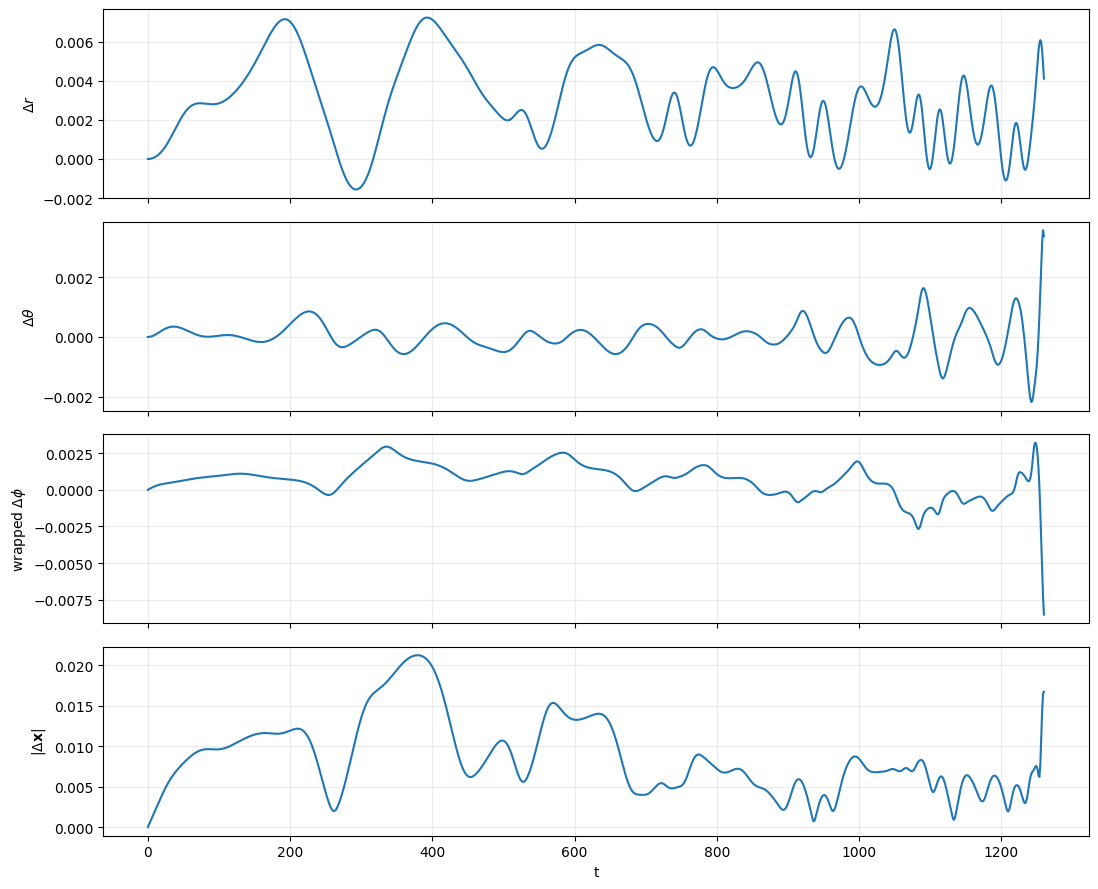

In [64]:
imported_traj, trajectory_summary = compare_trajectory_to_imported(
    traj,
    soln_true,
    t_test,
    a_true,
    gate_trajectory=trajectory_gate,
)

In [ ]:
dt_plot = assert_uniform_time(t_test).detach().item()
h_true = torch.complex(h_plus_true[0], h_cross_true[0])
h_pred = torch.complex(hp_trained, hc_trained)
plotSpectralDiagnostic(h_true, h_pred, dt=dt_plot)

In [66]:
def plotGeodesicProjections(soln_true, soln_pred, a_spin):
    """Visualizes the 'dance' in 3D and 2D projections [user history]."""
    # Use existing BL2Cartesian function for consistency [2]
    x_t, y_t, z_t = BoyerLindquist2Cartesian(soln_true[:,1], soln_true[:,2], soln_true[:,3], a_spin)
    x_p, y_p, z_p = BoyerLindquist2Cartesian(soln_pred[:,1], soln_pred[:,2], soln_pred[:,3], a_spin)

    fig = plt.figure(figsize=(15, 10))

    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.plot(x_t.detach(), y_t.detach(), z_t.detach(), 'r-', label='True')
    ax1.plot(x_p.detach(), y_p.detach(), z_p.detach(), 'g--', label='Pred')
    ax1.set_title("3D Geodesic Reconstruction")

    # Projections
    projections = [(222, x_t, y_t, x_p, y_p, "X-Y (Precession)"),
                   (223, x_t, z_t, x_p, z_p, "X-Z (Wobble)"),
                   (224, y_t, z_t, y_p, z_p, "Y-Z (Inclination)")]

    for pos, d1_t, d2_t, d1_p, d2_p, title in projections:
        ax = fig.add_subplot(pos)
        ax.plot(d1_t.detach(), d2_t.detach(), 'r-', alpha=0.6)
        ax.plot(d1_p.detach(), d2_p.detach(), 'g--', linewidth=2)
        ax.set_title(title)
        ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()


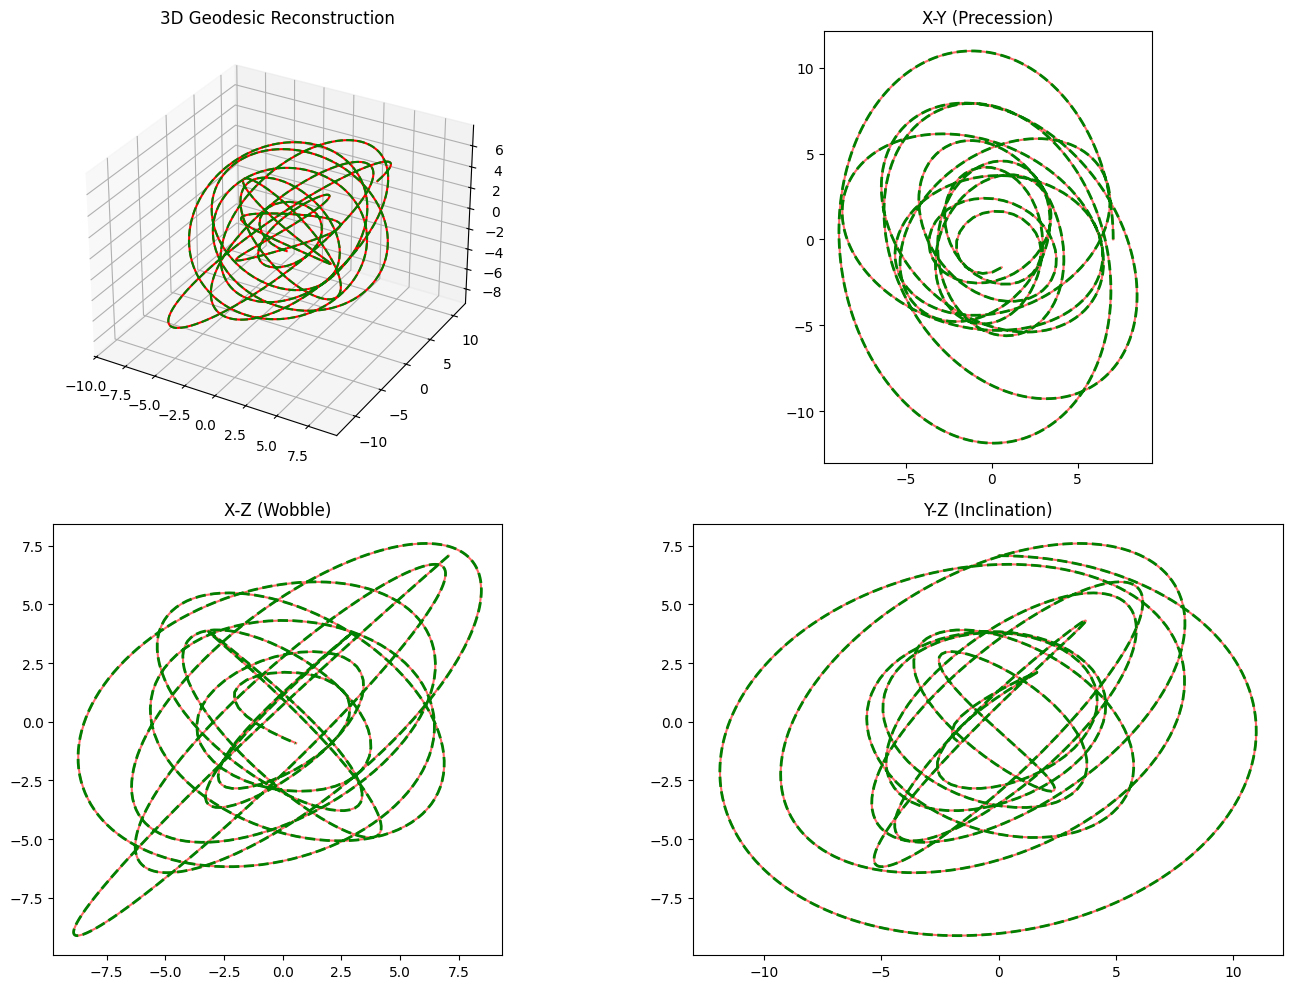

In [67]:
plotGeodesicProjections(trajectory_gate, traj, a_true)

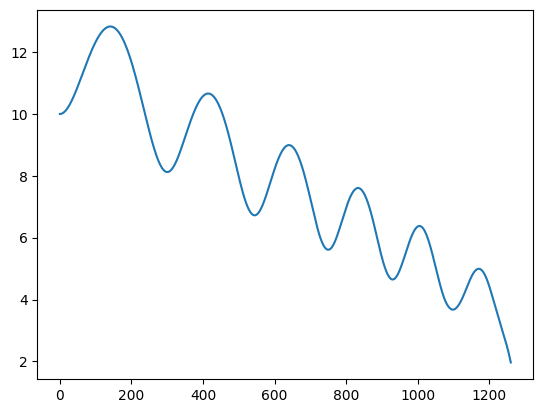

In [68]:
plt.plot(t_test, traj[:,1].detach().numpy())

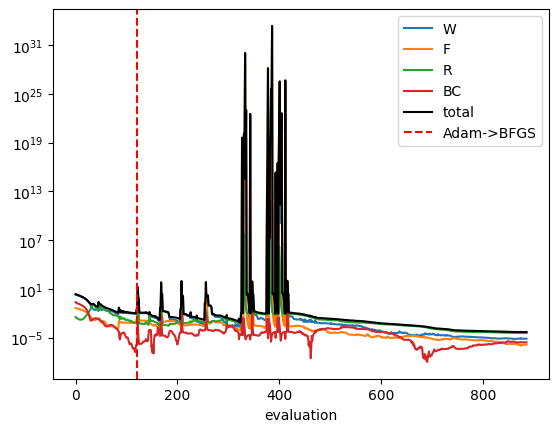

In [69]:
for history, label in [
    (waveform_loss_history, 'W'),
    (frequency_loss_history, 'F'),
    (ricci_loss_history, 'R'),
    (boundaryCondition_loss_history, 'BC')
]:
  plt.plot(history, label = label)

plt.plot(loss_history, 'k', label='total')
plt.axvline(
    adam_end,
    color="red",
    linestyle="--",
    label="Adam->BFGS"
)
plt.yscale('log')
plt.xlabel('evaluation')
plt.legend()

Stride of 10 Elements Comparison:

Time: tensor([   0.0000,   12.6126,   25.2252,   37.8378,   50.4504,   63.0631,
          75.6757,   88.2883,  100.9009,  113.5135,  126.1261,  138.7387,
         151.3513,  163.9640,  176.5766,  189.1892,  201.8018,  214.4144,
         227.0270,  239.6396,  252.2522,  264.8649,  277.4775,  290.0901,
         302.7027,  315.3153,  327.9279,  340.5405,  353.1531,  365.7657,
         378.3784,  390.9910,  403.6036,  416.2162,  428.8288,  441.4414,
         454.0540,  466.6667,  479.2793,  491.8919,  504.5045,  517.1171,
         529.7297,  542.3423,  554.9550,  567.5676,  580.1802,  592.7928,
         605.4054,  618.0180,  630.6307,  643.2433,  655.8559,  668.4685,
         681.0811,  693.6937,  706.3063,  718.9189,  731.5316,  744.1442,
         756.7568,  769.3694,  781.9820,  794.5946,  807.2072,  819.8198,
         832.4324,  845.0450,  857.6577,  870.2703,  882.8829,  895.4955,
         908.1081,  920.7207,  933.3333,  945.9460,  958.5586,  971.171

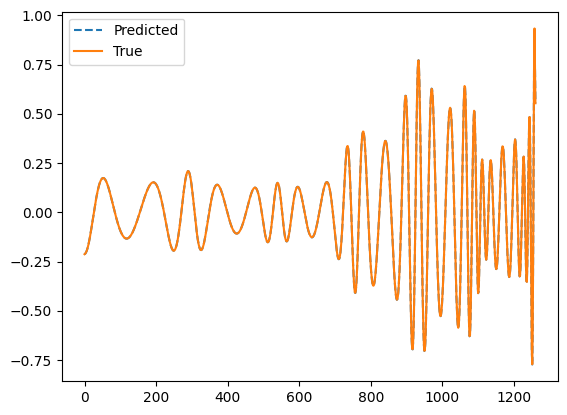

In [70]:
t_final_plot = len(t_test)

plt.plot(t_test.detach()[0:t_final_plot], hp_trained.detach()[0:t_final_plot], label = "Predicted", linestyle='dashed')
plt.plot(t_test.detach()[0:t_final_plot], h_plus_true[0][0:t_final_plot], label = "True", linestyle = "solid")

print("Stride of 10 Elements Comparison:\n")
print("Time:", t_test.detach()[::10])
print("hp_trained.detach:", hp_trained.detach()[::10])
print("h_plus_true:", h_plus_true[0][::10])

plt.legend()

In [71]:
from matplotlib.lines import Line2D

def compare_metrics(NN):
  M, a = 1.0, a_true
  r_plus = M + math.sqrt(M**2 - a**2)

  r_vals = np.linspace(2, ra_true, 20)
  θ_vals = [math.pi/2, math.pi/3, math.pi/4, math.pi/20]

  # fig, axes = plt.subplots(2, 3)

  figs = []
  colors = ['C0', 'C1', 'C2', 'C3']

  components = ["g_{tt}", "g_{rr}", "g_{θθ}", "g_{ϕϕ}", "g_{tϕ}"]
  component_index = [(0,0), (1,1), (2,2), (3,3), (0,3)]

  pred_by_component = []
  true_by_component = []

  for i in range(len(components)):
    fig, ax = plt.subplots(figsize=(8,6), dpi=150)
    true_metric, pred_metric = [], []
    for θ in θ_vals:
      for r in r_vals:
        r = torch.tensor(r, dtype = next(NN.parameters()).dtype)
        θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)

        true_g = g_Kerr(r, θ)[component_index[i]]
        pred_g = metric_from_network(NN, r, θ)[component_index[i]]

        pred_metric.append(pred_g)
        true_metric.append(true_g)

    pred_i = torch.stack(pred_metric).reshape(4,20).T
    true_i = torch.stack(true_metric).reshape(4,20).T
    pred_by_component.append(pred_i)
    true_by_component.append(true_i)

    for θ_idx in range(len(θ_vals)):
      ax.plot(r_vals, pred_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='dashed')
      ax.plot(r_vals, true_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='solid')

    handles = [Line2D([0], [0], color = colors[i], label=f"θ={round(θ_vals[i],2)}") for i in range(len(θ_vals))]
    handles += [
        Line2D([0], [0], color='k', linestyle='dashed', label='Predicted'),
        Line2D([0], [0], color='k', linestyle='solid', label='True')
    ]
    ax.legend(handles=handles)
    ax.set_title(f"${components[i]}$ Component")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(components[i])
    figs.append(fig)

  return figs, pred_by_component, true_by_component

def angular_comparison_metrics(NN):
  M, a = 1.0, a_true
  r_plus = M + math.sqrt(M**2 - a**2)

  r_vals = np.linspace(2, ra_true, 20)
  θ_vals = [math.pi/2, math.pi/3, math.pi/4, 0]

  figs = []
  colors = ['C0', 'C1', 'C2', 'C3']

  components = ["g_{tt}", "g_{rr}", "g_{θθ}", "g_{ϕϕ}", "g_{tϕ}"]
  component_index = [(0,0), (1,1), (2,2), (3,3), (0,3)]

  pred_diff_by_component = []
  true_diff_by_component = []

  for i in range(len(components)):
    fig, ax = plt.subplots(figsize=(8,6), dpi=150)
    true_metric, pred_metric = [], []
    for θ in θ_vals:
      for r in r_vals:
        r = torch.tensor(r, dtype = next(NN.parameters()).dtype)
        θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)

        true_g = g_Kerr(r, θ)[component_index[i]]
        pred_g = metric_from_network(NN, r, θ)[component_index[i]]

        pred_metric.append(pred_g)
        true_metric.append(true_g)

    pred_i = torch.stack(pred_metric).reshape(4,20).T
    true_i = torch.stack(true_metric).reshape(4,20).T

    pred_diff_i = pred_i - pred_i[:, 0:1]
    true_diff_i = true_i - true_i[:, 0:1]

    pred_diff_by_component.append(pred_diff_i)
    true_diff_by_component.append(true_diff_i)

    for θ_idx in range(len(θ_vals)):
      ax.plot(r_vals, pred_diff_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='dashed')
      ax.plot(r_vals, true_diff_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='solid')

    ax.set_title(f"${components[i]}$ Component Angular Difference")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(components[i])
    handles = [Line2D([0], [0], color = colors[i], label=f"θ={round(θ_vals[i],2)}") for i in range(len(θ_vals))]
    handles += [
        Line2D([0], [0], color='k', linestyle='dashed', label='Predicted'),
        Line2D([0], [0], color='k', linestyle='solid', label='True')
    ]
    ax.legend(handles=handles)
    figs.append(fig)

  return figs, pred_diff_by_component, true_diff_by_component

/tmp/ipykernel_2691/3873156370.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)


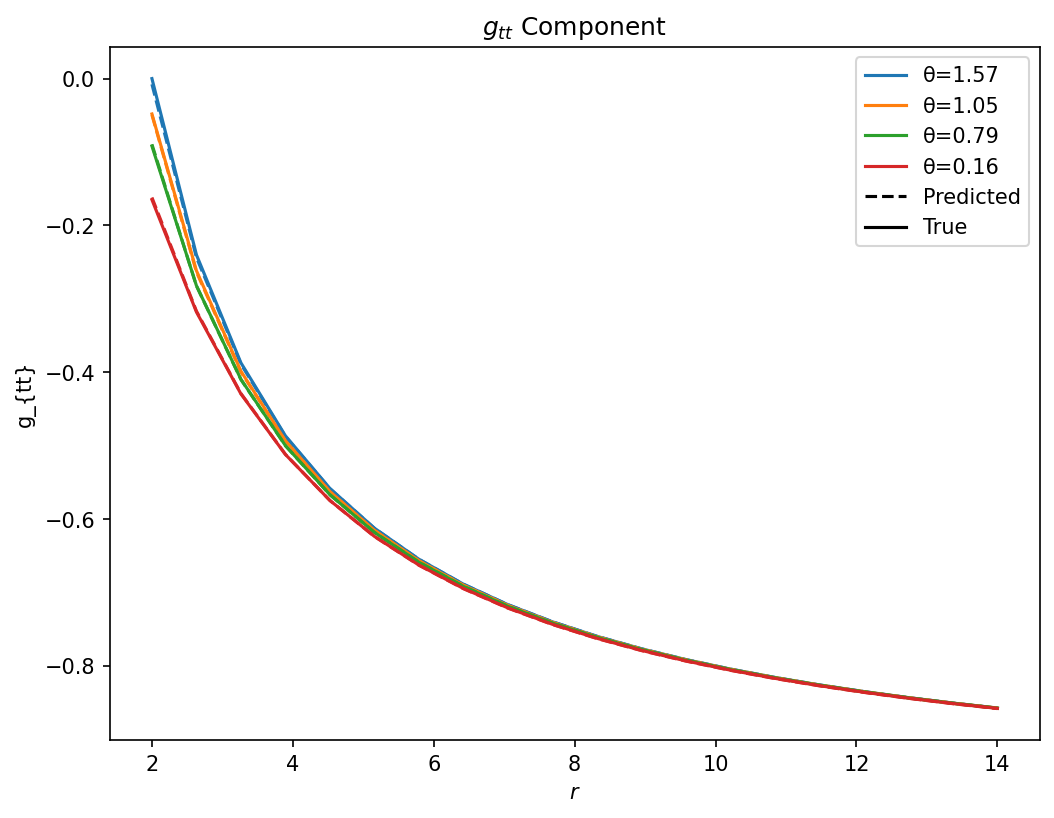

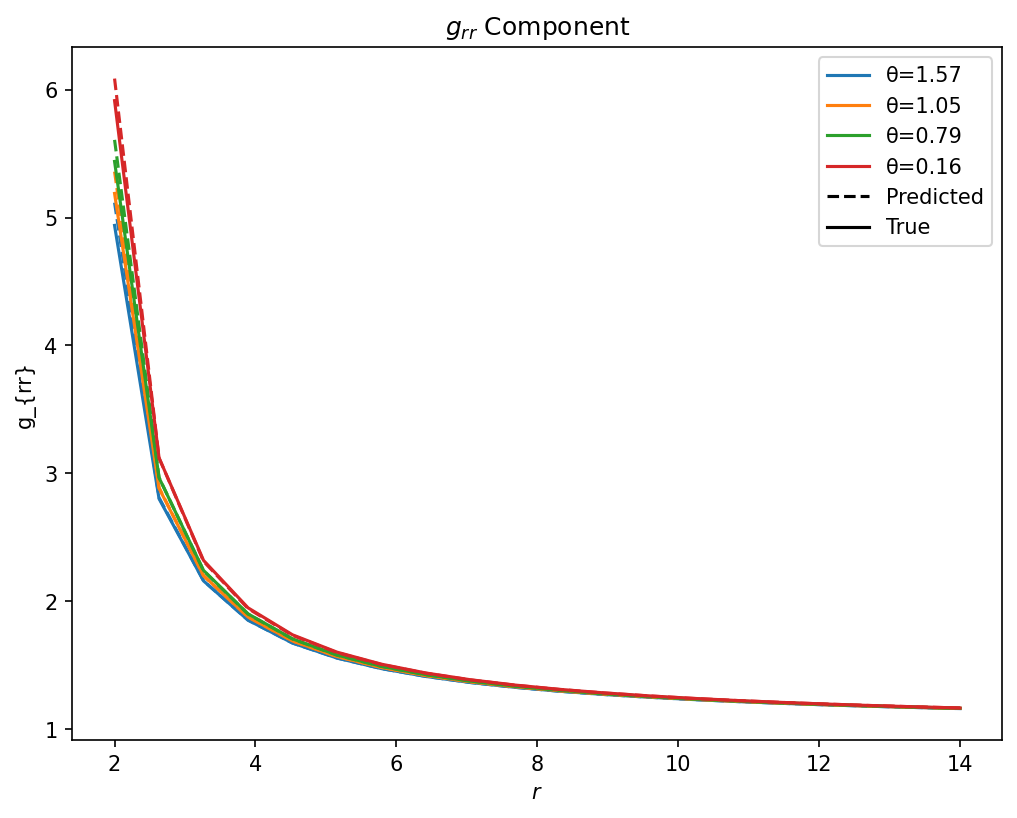

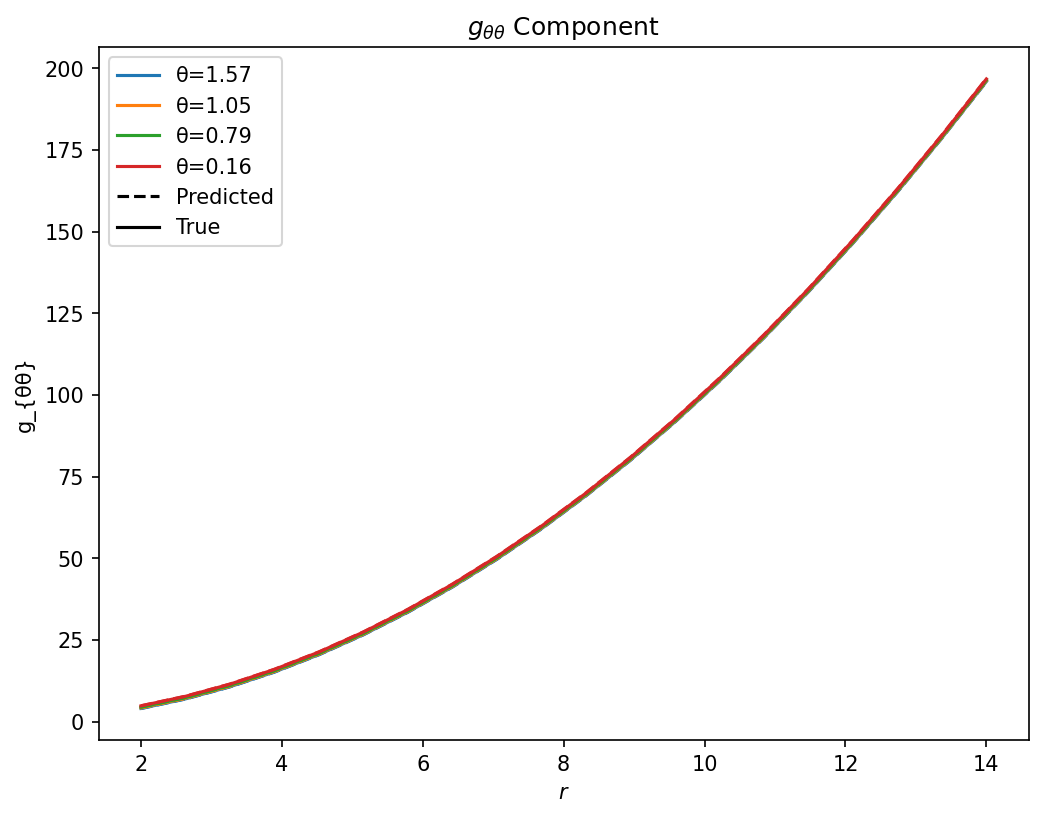

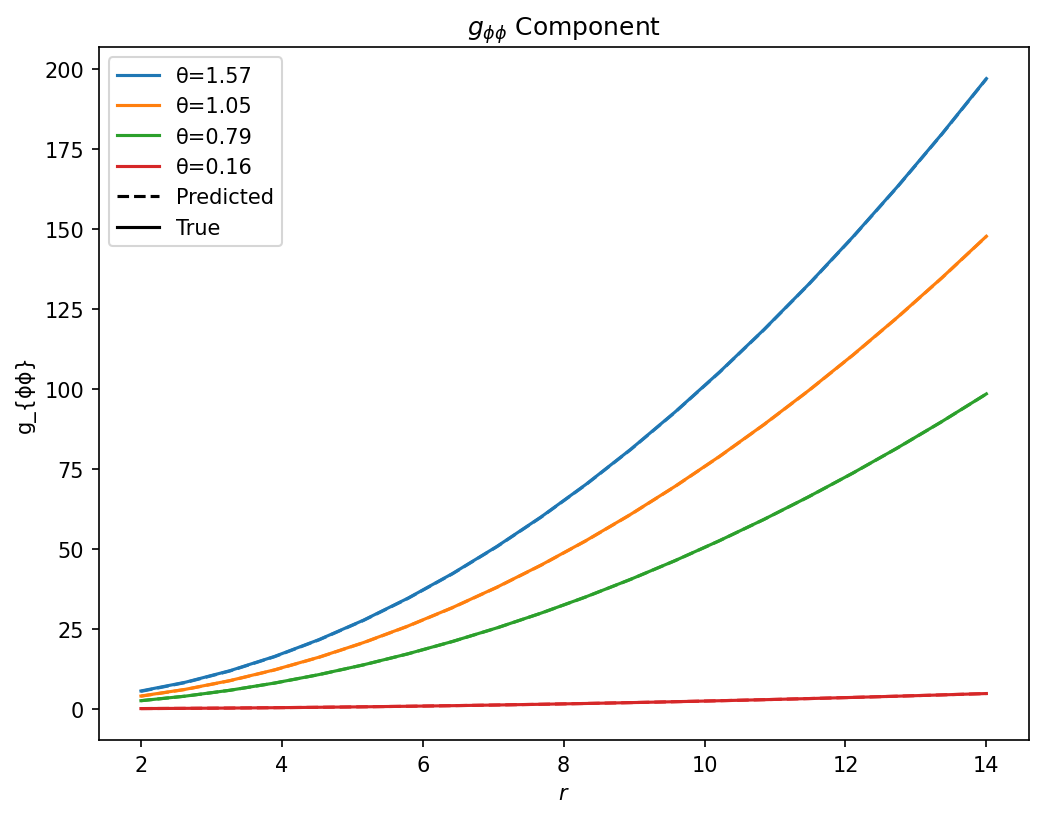

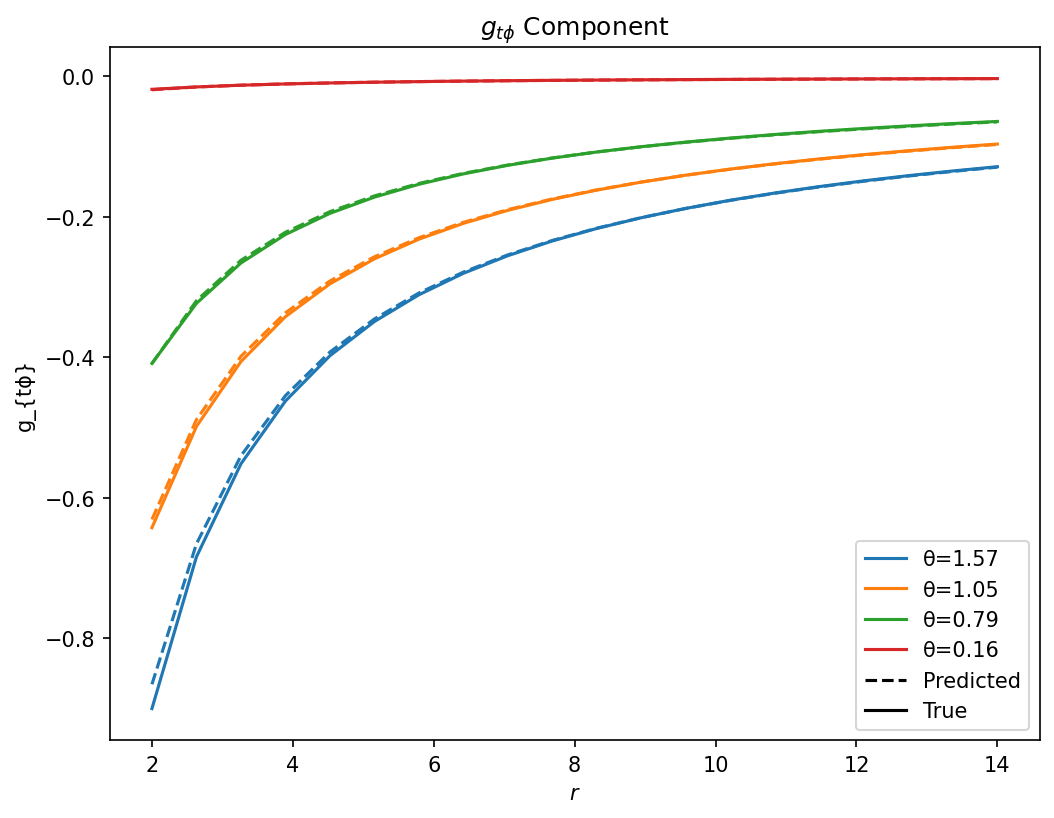

In [72]:
fig, a, b = compare_metrics(net)

/tmp/ipykernel_2691/3873156370.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)


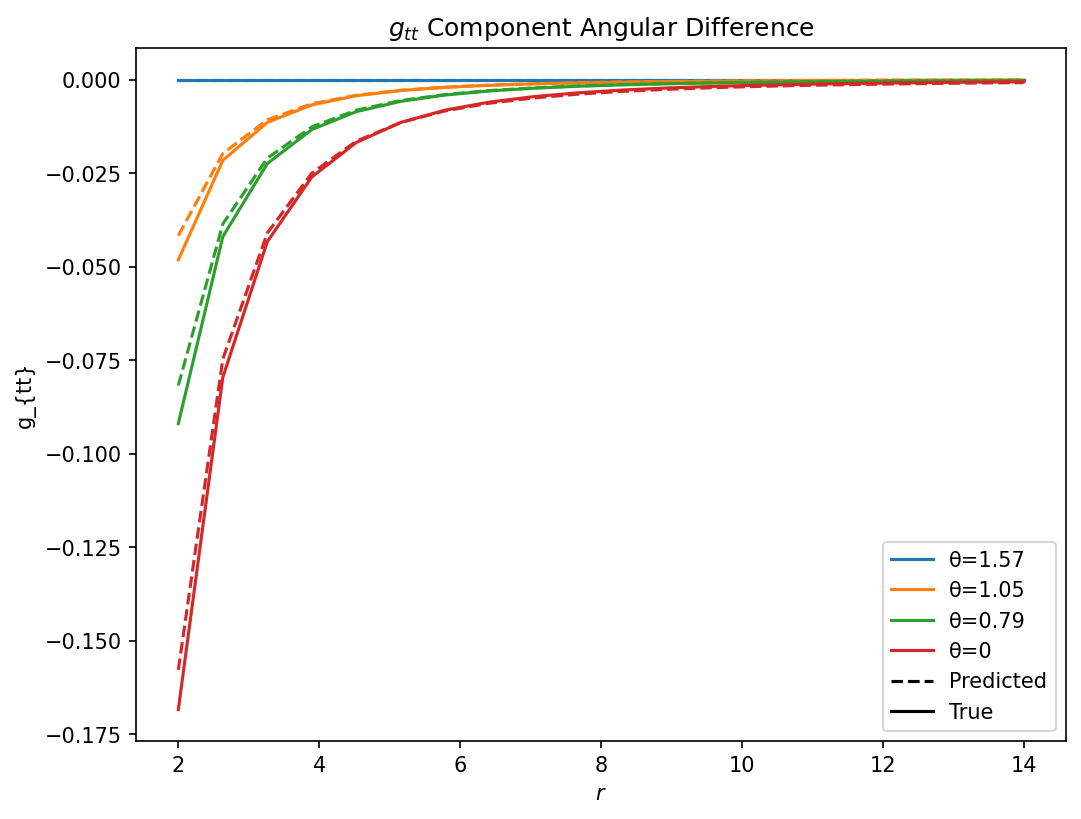

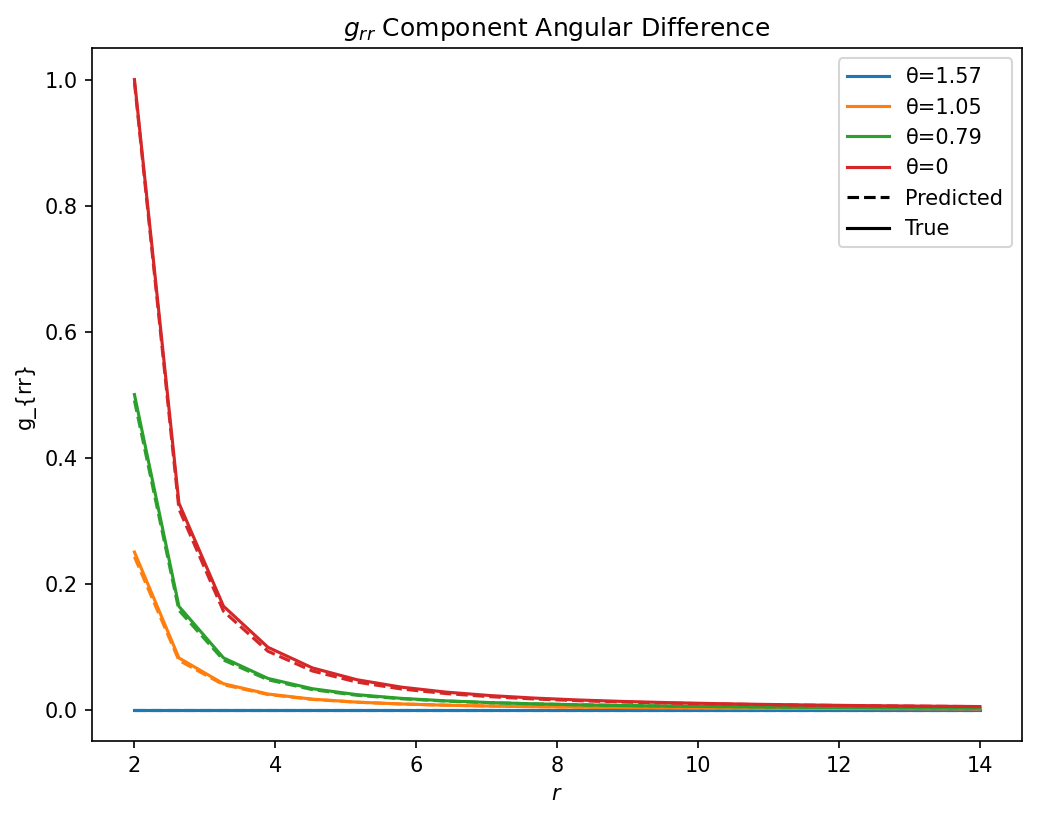

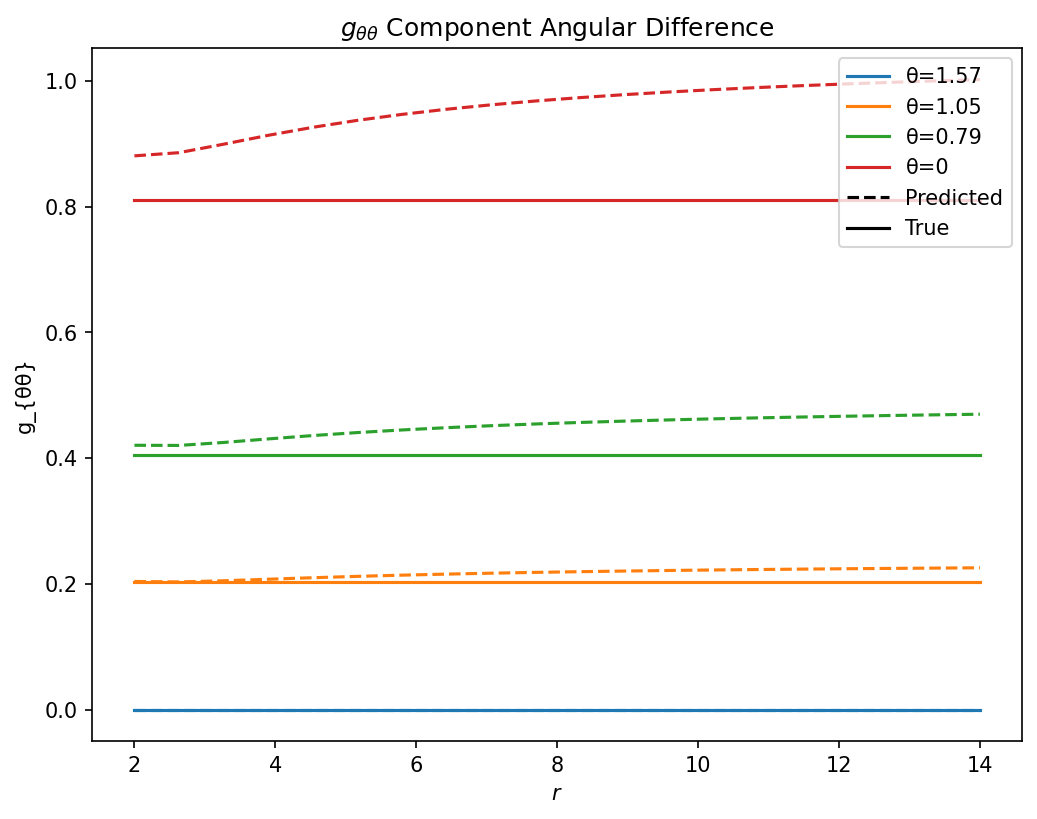

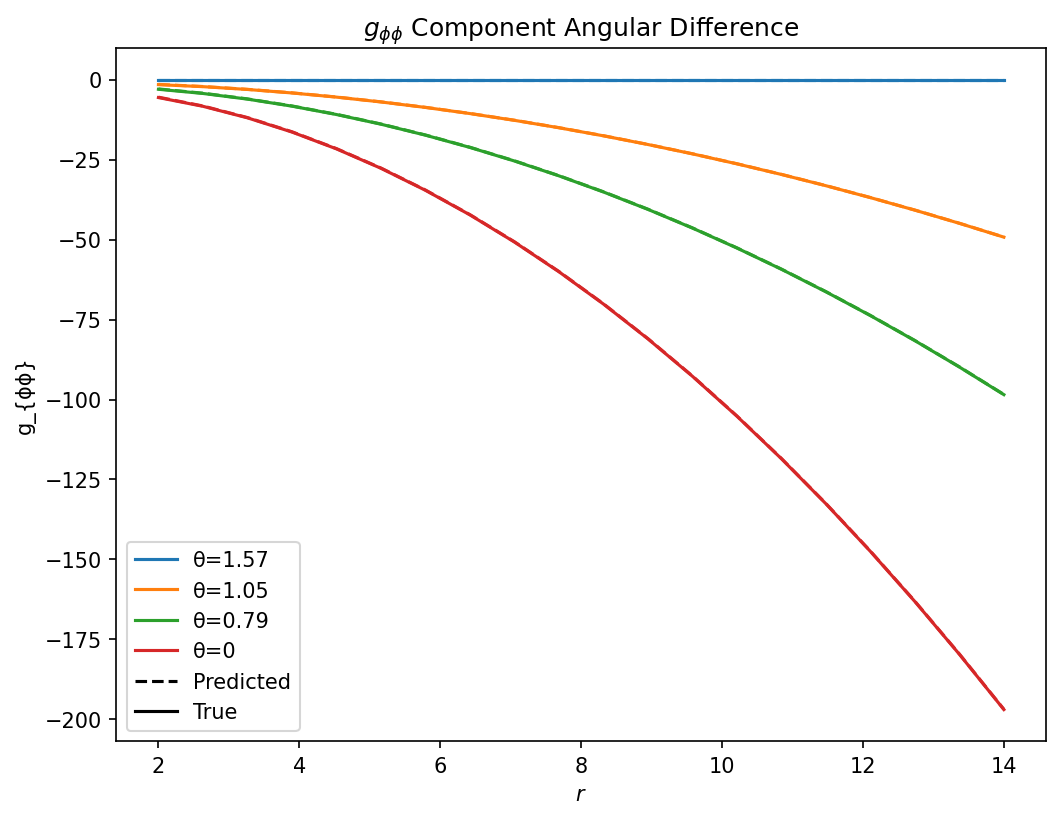

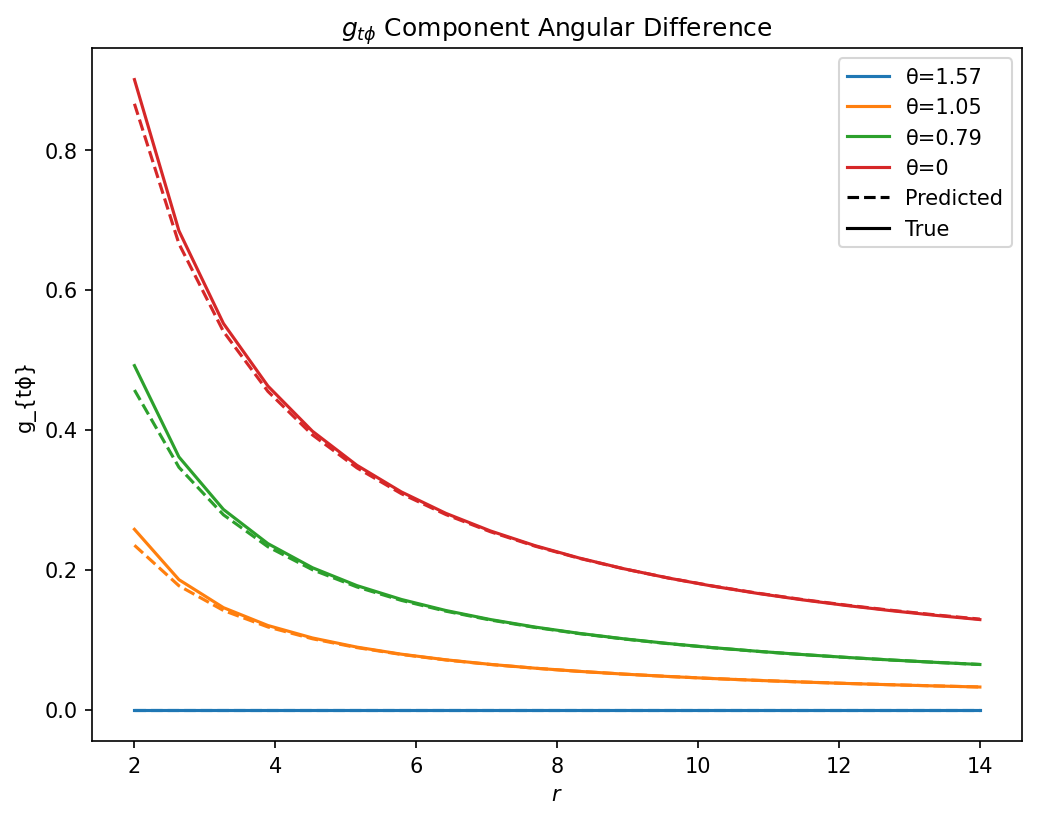

In [73]:
def percent_diff(pred, true):
  return 100 * abs(pred - true) / abs(true)

b, c, d = angular_comparison_metrics(net)

In [ ]:
from prettytable import PrettyTable

def print_metric_error_table(network, r_grid = [2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 20]):

    θ_grid = [π/20, π/4, π/3, π/2]

    components = {
        "g_tt": (0,0),
        "g_rr": (1,1),
        "g_θθ": (2,2),
        "g_ϕϕ": (3,3),
        "g_tϕ": (0,3),
    }

    errors = {name: [] for name in components}
    param = next(network.parameters())

    with torch.no_grad():
      for r in r_grid:
        pred_at_r = []
        true_at_r = []

        for θ in θ_grid:
          r_t = torch.tensor(r, dtype = param.dtype)
          θ_t = torch.tensor(θ, dtype = param.dtype)

          pred_at_r.append(metric_from_network(network, r_t, θ_t))
          true_at_r.append(g_Kerr(r_t, θ_t))

        pred_at_r = torch.stack(pred_at_r)
        true_at_r = torch.stack(true_at_r)

        for name, (μ, ν) in components.items():
          error = rel_L2_error(
              pred_at_r[:, μ, ν],
              true_at_r[:, μ, ν]
          )

          errors[name].append(error.item())

    table = PrettyTable()
    table.title = "Metric Relative L2 Error Across θ (%)"
    table.field_names = [
        "Component",
        *[f"r={r:g}" for r in r_grid]
    ]
    table.float_format = ".2"

    for name in components:
      table.add_row([name, *errors[name]])

    print(table)
    return table, errors


In [75]:
metric_table, metric_errors = print_metric_error_table(net)

+-----------------------------------------------------------------------------------------------+
|                             Metric Relative L2 Error Across θ (%)                             |
+-----------+------+------+------+------+------+------+------+------+------+------+------+------+
| Component | r=2  | r=3  | r=4  | r=5  | r=6  | r=7  | r=8  | r=10 | r=12 | r=14 | r=16 | r=20 |
+-----------+------+------+------+------+------+------+------+------+------+------+------+------+
|    g_tt   | 4.49 | 0.40 | 0.09 | 0.02 | 0.02 | 0.02 | 0.02 | 0.02 | 0.02 | 0.01 | 0.01 | 0.01 |
|    g_rr   | 3.20 | 0.15 | 0.16 | 0.12 | 0.08 | 0.06 | 0.04 | 0.03 | 0.02 | 0.02 | 0.02 | 0.02 |
|    g_θθ   | 0.80 | 0.41 | 0.28 | 0.20 | 0.15 | 0.12 | 0.10 | 0.07 | 0.05 | 0.04 | 0.03 | 0.02 |
|    g_ϕϕ   | 1.89 | 0.75 | 0.43 | 0.29 | 0.21 | 0.15 | 0.12 | 0.08 | 0.06 | 0.04 | 0.03 | 0.02 |
|    g_tϕ   | 3.10 | 2.10 | 1.56 | 1.13 | 0.77 | 0.48 | 0.25 | 0.17 | 0.43 | 0.64 | 0.81 | 1.05 |
+-----------+------+

In [76]:
from scipy.optimize import brentq

def horizon_and_rotation_diagnostics(
    network,
    M=1.0,
    a=None,
    r_lo=1.0,
    r_hi=2.01,
    n_r=401,
    theta_values=None,
    far_field_radii=(4.0, 10.0, 14.0, 20.0),
):
    if a is None:
        a = a_true

    if theta_values is None:
        theta_values = [
            math.pi / 20,
            math.pi / 4,
            math.pi / 3,
            math.pi / 2,
        ]

    reference = next(network.parameters())
    dtype = reference.dtype
    device = reference.device

    def scalar_tensor(value):
        return torch.tensor(
            value,
            dtype=dtype,
            device=device,
        )

    def learned_metric(r, theta):
        return metric_from_network(
            network,
            scalar_tensor(r),
            scalar_tensor(theta),
        )

    def inverse_grr_value(r, theta):
        # Valid here because the ansatz has no r cross-terms.
        with torch.no_grad():
            g = learned_metric(r, theta)
            return float((1.0 / g[1, 1]).detach().cpu())

    def metric_rotation_quantities(g, r, theta):
        g_tt = float(g[0, 0].detach().cpu())
        g_tphi = float(g[0, 3].detach().cpu())
        g_phiphi = float(g[3, 3].detach().cpu())

        sin2 = math.sin(theta) ** 2

        omega = -g_tphi / g_phiphi
        J_eff = -r * g_tphi / (2.0 * sin2)

        return {
            "g_tt": g_tt,
            "g_tphi": g_tphi,
            "g_phiphi": g_phiphi,
            "omega": omega,
            "J_eff": J_eff,
        }

    def chi_squared(q, Omega):
        return (
            q["g_tt"]
            + 2.0 * Omega * q["g_tphi"]
            + Omega**2 * q["g_phiphi"]
        )

    # Existing differentiable soft-root output, for comparison.
    metric_fn = lambda x: metric_from_network(
        network,
        x[1],
        x[2],
    )

    with torch.no_grad():
        soft_bc_loss, soft_roots = boundaryConditionLoss(metric_fn)

    soft_root_values = [
        float(root.detach().cpu())
        for root in soft_roots
    ]

    print(
        "BC soft roots at θ=[0, π/2]:",
        [f"{root:.8f}" for root in soft_root_values],
    )
    print(
        f"BC raw loss: {float(soft_bc_loss.detach().cpu()):.6e}"
    )

    # Hard sign-changing roots on a denser diagnostic grid.
    radial_grid = np.linspace(r_lo, r_hi, n_r)
    root_records = []

    for theta in theta_values:
        values = np.array([
            inverse_grr_value(r, theta)
            for r in radial_grid
        ])

        candidate_roots = []

        def add_unique_root(root):
            if not any(
                abs(root - existing) < 1e-8
                for existing in candidate_roots
            ):
                candidate_roots.append(root)

        for i in range(len(radial_grid) - 1):
            y0 = values[i]
            y1 = values[i + 1]

            if not (np.isfinite(y0) and np.isfinite(y1)):
                continue

            if y0 == 0.0:
                add_unique_root(float(radial_grid[i]))
            elif y0 * y1 < 0.0:
                root = brentq(
                    lambda radius: inverse_grr_value(
                        radius,
                        theta,
                    ),
                    radial_grid[i],
                    radial_grid[i + 1],
                )
                add_unique_root(float(root))

        candidate_roots.sort()

        # The event-horizon candidate is the outermost root.
        hard_root = (
            candidate_roots[-1]
            if candidate_roots
            else float("nan")
        )

        endpoint_product = values[0] * values[-1]
        endpoint_bracket = (
            np.isfinite(endpoint_product)
            and endpoint_product <= 0.0
        )

        record = {
            "theta": theta,
            "root": hard_root,
            "n_crossings": len(candidate_roots),
            "endpoint_bracket": endpoint_bracket,
            "g_lo": values[0],
            "g_hi": values[-1],
        }

        if np.isfinite(hard_root):
            with torch.no_grad():
                g_root = learned_metric(
                    hard_root,
                    theta,
                )

            record["root_quantities"] = (
                metric_rotation_quantities(
                    g_root,
                    hard_root,
                    theta,
                )
            )
        else:
            record["root_quantities"] = None

        root_records.append(record)

    finite_roots = np.array([
        record["root"]
        for record in root_records
        if np.isfinite(record["root"])
    ])

    omega_h_values = np.array([
        record["root_quantities"]["omega"]
        for record in root_records
        if record["root_quantities"] is not None
    ])

    r_plus = M + math.sqrt(M**2 - a**2)
    Omega_H_true = a / (2.0 * M * r_plus)

    rH_mean = (
        float(np.mean(finite_roots))
        if len(finite_roots)
        else float("nan")
    )
    rH_std = (
        float(np.std(finite_roots))
        if len(finite_roots)
        else float("nan")
    )

    Omega_H_learned = (
        float(np.mean(omega_h_values))
        if len(omega_h_values)
        else float("nan")
    )
    Omega_H_learned_std = (
        float(np.std(omega_h_values))
        if len(omega_h_values)
        else float("nan")
    )

    horizon_table = PrettyTable()
    horizon_table.title = "Hard Horizon and Killing-Generator Diagnostics"
    horizon_table.field_names = [
        "θ",
        "r_H",
        "# roots",
        "endpoint bracket?",
        "ω(r_H,θ)",
        "χ²(r_H; Ω_Kerr)",
        "χ²(r_H; <ω_H>)",
        "χ²(r_+; Ω_Kerr)",
    ]

    for record in root_records:
        theta = record["theta"]
        root = record["root"]
        q_root = record["root_quantities"]

        if q_root is None:
            horizon_table.add_row([
                f"{theta:.5f}",
                "none",
                record["n_crossings"],
                record["endpoint_bracket"],
                "nan",
                "nan",
                "nan",
                "nan",
            ])
            continue

        chi_root_true_Omega = chi_squared(
            q_root,
            Omega_H_true,
        )
        chi_root_learned_Omega = chi_squared(
            q_root,
            Omega_H_learned,
        )

        with torch.no_grad():
            g_at_true_rplus = learned_metric(
                r_plus,
                theta,
            )

        q_at_true_rplus = metric_rotation_quantities(
            g_at_true_rplus,
            r_plus,
            theta,
        )
        chi_at_true_rplus = chi_squared(
            q_at_true_rplus,
            Omega_H_true,
        )

        horizon_table.add_row([
            f"{theta:.5f}",
            f"{root:.8f}",
            record["n_crossings"],
            record["endpoint_bracket"],
            f"{q_root['omega']:.8f}",
            f"{chi_root_true_Omega:+.4e}",
            f"{chi_root_learned_Omega:+.4e}",
            f"{chi_at_true_rplus:+.4e}",
        ])

    print(horizon_table)

    print(f"True Kerr r_+          = {r_plus:.10f}")
    print(f"Learned hard-root mean = {rH_mean:.10f}")
    print(f"Learned hard-root std  = {rH_std:.4e}")

    if np.isfinite(rH_mean):
        print(
            "r_H relative error     = "
            f"{100 * (rH_mean - r_plus) / r_plus:+.4f}%"
        )

    print(f"True Kerr Ω_H          = {Omega_H_true:.10f}")
    print(f"Learned <ω_H>          = {Omega_H_learned:.10f}")
    print(f"Learned std(ω_H)       = {Omega_H_learned_std:.4e}")

    if np.isfinite(Omega_H_learned):
        print(
            "Ω_H relative error     = "
            f"{100 * (Omega_H_learned - Omega_H_true) / Omega_H_true:+.4f}%"
        )

    print(
        "Endpoint brackets: "
        f"{sum(r['endpoint_bracket'] for r in root_records)}"
        f"/{len(root_records)}"
    )

    # Radial frame-dragging and effective-angular-momentum table.
    rotation_thetas = [
        math.pi / 4,
        math.pi / 3,
        math.pi / 2,
    ]

    rotation_table = PrettyTable()
    rotation_table.title = "Frame Dragging and Effective Angular Momentum"
    rotation_table.field_names = [
        "r",
        "θ",
        "ω_NN",
        "ω_Kerr",
        "ω error (%)",
        "J_eff NN",
        "J_eff Kerr",
        "J error (%)",
    ]

    for radius in far_field_radii:
        for theta in rotation_thetas:
            r_tensor = scalar_tensor(radius)
            theta_tensor = scalar_tensor(theta)

            with torch.no_grad():
                g_nn = metric_from_network(
                    network,
                    r_tensor,
                    theta_tensor,
                )
                g_true = g_Kerr(
                    r_tensor,
                    theta_tensor,
                    M=M,
                    a=a,
                )

            q_nn = metric_rotation_quantities(
                g_nn,
                radius,
                theta,
            )
            q_true = metric_rotation_quantities(
                g_true,
                radius,
                theta,
            )

            omega_error = (
                100
                * abs(q_nn["omega"] - q_true["omega"])
                / (abs(q_true["omega"]) + 1e-30)
            )
            J_error = (
                100
                * abs(q_nn["J_eff"] - q_true["J_eff"])
                / (abs(q_true["J_eff"]) + 1e-30)
            )

            rotation_table.add_row([
                f"{radius:.1f}",
                f"{theta:.5f}",
                f"{q_nn['omega']:.6e}",
                f"{q_true['omega']:.6e}",
                f"{omega_error:.3f}",
                f"{q_nn['J_eff']:.6f}",
                f"{q_true['J_eff']:.6f}",
                f"{J_error:.3f}",
            ])

    print(rotation_table)

    return {
        "soft_roots": soft_root_values,
        "hard_root_records": root_records,
        "r_plus_true": r_plus,
        "rH_mean": rH_mean,
        "rH_std": rH_std,
        "Omega_H_true": Omega_H_true,
        "Omega_H_learned": Omega_H_learned,
        "Omega_H_learned_std": Omega_H_learned_std,
    }

In [77]:
horizon_diagnostics = horizon_and_rotation_diagnostics(net)

BC soft roots at θ=[0, π/2]: ['1.50717958', '1.51464624', '1.51916563', '1.51615190']
BC raw loss: 2.600100e-05
+----------------------------------------------------------------------------------------------------------------------+
|                                    Hard Horizon and Killing-Generator Diagnostics                                    |
+---------+------------+---------+-------------------+------------+-----------------+----------------+-----------------+
|    θ    |    r_H     | # roots | endpoint bracket? |  ω(r_H,θ)  | χ²(r_H; Ω_Kerr) | χ²(r_H; <ω_H>) | χ²(r_+; Ω_Kerr) |
+---------+------------+---------+-------------------+------------+-----------------+----------------+-----------------+
| 0.15708 | 1.50767416 |    1    |        True       | 0.31138799 |   -9.3213e-03   |  -9.2960e-03   |   +1.7060e-02   |
| 0.78540 | 1.51843437 |    1    |        True       | 0.29299314 |   -9.8294e-03   |  -1.0565e-02   |   +1.6548e-02   |
| 1.04720 | 1.51879955 |    1    |       

# Save Results

In [78]:
torch.save(net.state_dict(), FINAL_PATH)

In [79]:
# Optional extra continuation. Disabled so Run All has one controlled experiment.
RUN_EXTRA_BFGS = False

if RUN_EXTRA_BFGS:
  bfgs_start_time = time.time()
  result_continued = run_bfgs_stage(window=1000, maxiter=100)
  result = result_continued


In [80]:
if RUN_EXTRA_BFGS:
  t_test = t_full
  h_plus_true = hp_full
  h_cross_true = hc_full

  final_total_2, final_w_2, final_r_2, final_f_2, final_b_2, final_roots_2 = loss(net)
  log_diagnostics(
      net, final_total_2, final_w_2, final_r_2, final_f_2, final_b_2,
      final_roots_2, n + result_continued.nit, time.time() - bfgs_start_time
  )


In [81]:
t_test = t_full
h_plus_true = hp_full
h_cross_true = hc_full

GTPHI_ALPHA = None
WHOLE_METRIC_ALPHA = None

torch.save(net.state_dict(), FINAL_PATH)

_DIAG_STATE = {
    name: value.detach().clone()
    for name, value in net.state_dict().items()
}

In [82]:
"""
Sonar v14 post-run curvature diagnostics.

Paste this entire file into ONE new Colab code cell after the last existing
Sonar v14 cell. It analyzes the actual weighted v14 objective

    P_WAVEFORM * L_W + P_RICCI * L_R
    + P_FREQUENCY * L_F + P_BC * L_BC

without introducing a supervised Kerr loss.

The audit uses central finite differences of the exact v14 term gradients to
construct Hessian projections in a reproducible random parameter subspace.
It therefore avoids refactoring the differentiable ODE/Ricci pipeline.

Requirements already defined by Sonar v14:
    net, loss, t_full, hp_full, hc_full,
    t_test, h_plus_true, h_cross_true,
    P_WAVEFORM, P_RICCI, P_FREQUENCY, P_BC,
    GTPHI_ALPHA, WHOLE_METRIC_ALPHA, FINAL_PATH,
    torch, np, plt, PrettyTable
"""


def _v14_flatten_gradients(grads, params):
    return torch.cat([
        (
            grad.reshape(-1)
            if grad is not None
            else torch.zeros_like(param).reshape(-1)
        )
        for grad, param in zip(grads, params)
    ])


def _v14_set_parameter_vector(network, vector):
    reference = next(network.parameters())
    vector = vector.to(dtype=reference.dtype, device=reference.device)
    with torch.no_grad():
        torch.nn.utils.vector_to_parameters(vector, network.parameters())


def _v14_weighted_term_gradients(network):
    """One v14 loss evaluation plus gradients of each weighted loss term."""
    params = list(network.parameters())
    network.zero_grad(set_to_none=True)

    total, waveform, ricci, frequency, boundary, _ = loss(network)

    weighted_terms = {
        "W": P_WAVEFORM * waveform,
        "R": P_RICCI * ricci,
        "F": P_FREQUENCY * frequency,
        "BC": P_BC * boundary,
    }

    gradients = {}
    labels = list(weighted_terms)

    for index, label in enumerate(labels):
        term = weighted_terms[label]

        if term.requires_grad:
            term_grads = torch.autograd.grad(
                term,
                params,
                retain_graph=(index < len(labels) - 1),
                create_graph=False,
                allow_unused=True,
            )
            flat = _v14_flatten_gradients(term_grads, params)
        else:
            flat = torch.cat([
                torch.zeros_like(param).reshape(-1)
                for param in params
            ])

        gradients[label] = flat.detach()

    values = {
        label: float(term.detach().cpu())
        for label, term in weighted_terms.items()
    }

    weighted_sum = sum(weighted_terms.values())
    total_mismatch = abs(
        float(total.detach().cpu())
        - float(weighted_sum.detach().cpu())
    )

    return values, gradients, float(total.detach().cpu()), total_mismatch


def _v14_cosine(a, b, eps=1e-300):
    denominator = torch.linalg.vector_norm(a) * torch.linalg.vector_norm(b)
    if float(denominator.detach().cpu()) <= eps:
        return float("nan")
    return float((torch.dot(a, b) / denominator).detach().cpu())


def _v14_print_base_gradient_report(values, gradients, total_value):
    observational = gradients["W"] + gradients["F"]
    physics = gradients["R"] + gradients["BC"]
    total_gradient = observational + physics

    table = PrettyTable()
    table.title = "Sonar v14 weighted losses and gradients at the final network"
    table.field_names = [
        "term",
        "weighted loss",
        "|gradient|",
        "cos(grad, total)",
    ]

    rows = {
        "W": (values["W"], gradients["W"]),
        "F": (values["F"], gradients["F"]),
        "R": (values["R"], gradients["R"]),
        "BC": (values["BC"], gradients["BC"]),
        "OBS=W+F": (values["W"] + values["F"], observational),
        "PHYS=R+BC": (values["R"] + values["BC"], physics),
        "TOTAL": (total_value, total_gradient),
    }

    for label, (value, gradient) in rows.items():
        table.add_row([
            label,
            f"{value:.6e}",
            f"{float(torch.linalg.vector_norm(gradient).cpu()):.6e}",
            f"{_v14_cosine(gradient, total_gradient):+.6f}",
        ])

    print(table)

    cosine_table = PrettyTable()
    cosine_table.title = "Pairwise weighted-gradient cosines"
    cosine_table.field_names = [""] + list(gradients)

    for label_a, grad_a in gradients.items():
        cosine_table.add_row([
            label_a,
            *[
                f"{_v14_cosine(grad_a, grad_b):+.5f}"
                for grad_b in gradients.values()
            ],
        ])

    print(cosine_table)


def _v14_sorted_absolute_spectrum(matrix):
    eigenvalues = torch.linalg.eigvalsh(matrix)
    order = torch.argsort(eigenvalues.abs(), descending=True)
    return eigenvalues[order]


def _v14_plot_projected_spectra(projected):
    plt.figure(figsize=(8, 4.5))

    styles = {
        "TOTAL": ("o-", "total: W+F+R+BC"),
        "OBS": ("s--", "observational: W+F"),
        "PHYS": ("^--", "physics: R+BC"),
    }

    tiny = torch.finfo(projected["TOTAL"].dtype).tiny

    for label, (style, legend_label) in styles.items():
        spectrum = _v14_sorted_absolute_spectrum(projected[label])
        y = spectrum.abs().clamp_min(tiny).detach().cpu().numpy()
        plt.semilogy(range(1, len(y) + 1), y, style, label=legend_label)

    plt.xlabel("projected curvature rank (largest |eigenvalue| first)")
    plt.ylabel("|projected Hessian eigenvalue|")
    plt.title("Sonar v14 local curvature spectrum (random parameter subspace)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def _v14_complementarity_report(
    projected,
    sloppy_fraction=1e-3,
    make_plot=True,
):
    """
    Diagonalize the physics curvature R+BC, then measure every v14 term along
    those same directions. This is the v14-native version of asking whether
    the observational losses constrain directions left sloppy by the physics
    losses.
    """
    physics_eigenvalues, physics_basis = torch.linalg.eigh(projected["PHYS"])
    order = torch.argsort(physics_eigenvalues.abs())
    physics_eigenvalues = physics_eigenvalues[order]
    physics_basis = physics_basis[:, order]

    directional = {}
    for label in ["W", "F", "R", "BC", "OBS", "PHYS", "TOTAL"]:
        rotated = physics_basis.T @ projected[label] @ physics_basis
        directional[label] = torch.diagonal(rotated)

    physics_scale = max(
        float(directional["PHYS"].abs().max().detach().cpu()),
        1e-300,
    )
    observational_scale = max(
        float(directional["OBS"].abs().max().detach().cpu()),
        1e-300,
    )

    physics_floor = sloppy_fraction * physics_scale
    observational_floor = sloppy_fraction * observational_scale

    table = PrettyTable()
    table.title = (
        "Which v14 terms constrain the physics-loss sloppy directions?"
    )
    table.field_names = [
        "rank",
        "k_W",
        "k_F",
        "k_R",
        "k_BC",
        "k_OBS",
        "k_PHYS",
        "k_TOTAL",
        "local verdict",
    ]

    verdicts = []

    for index in range(len(physics_eigenvalues)):
        k_obs = float(directional["OBS"][index].detach().cpu())
        k_phys = float(directional["PHYS"][index].detach().cpu())

        physics_sloppy = abs(k_phys) <= physics_floor
        observational_sloppy = abs(k_obs) <= observational_floor

        if physics_sloppy and not observational_sloppy:
            verdict = "OBS constrains PHYS-sloppy"
        elif physics_sloppy and observational_sloppy:
            verdict = "flat in both"
        elif not physics_sloppy and observational_sloppy:
            verdict = "PHYS dominates"
        else:
            verdict = "both constrain"

        if float(directional["TOTAL"][index].detach().cpu()) < 0.0:
            verdict += "; total negative"

        verdicts.append(verdict)

        table.add_row([
            index + 1,
            f"{float(directional['W'][index].cpu()):+.3e}",
            f"{float(directional['F'][index].cpu()):+.3e}",
            f"{float(directional['R'][index].cpu()):+.3e}",
            f"{float(directional['BC'][index].cpu()):+.3e}",
            f"{k_obs:+.3e}",
            f"{k_phys:+.3e}",
            f"{float(directional['TOTAL'][index].cpu()):+.3e}",
            verdict,
        ])

    print(table)
    print(
        f"sloppy thresholds: |k_PHYS| <= {physics_floor:.3e}, "
        f"|k_OBS| <= {observational_floor:.3e}"
    )
    print(
        "OBS = weighted waveform + frequency curvature; "
        "PHYS = weighted Ricci + boundary curvature."
    )
    print(
        "Signed negative curvature can be a real saddle direction or finite-"
        "difference/solver noise; repeat with a second rel_step before making "
        "that claim."
    )

    if make_plot:
        x = (
            directional["PHYS"].abs().clamp_min(1e-300)
            .detach().cpu().numpy()
        )
        y = (
            directional["OBS"].abs().clamp_min(1e-300)
            .detach().cpu().numpy()
        )

        plt.figure(figsize=(6.5, 5.5))
        plt.loglog(x, y, "o")
        plt.axvline(physics_floor, color="tab:blue", linestyle="--")
        plt.axhline(observational_floor, color="tab:orange", linestyle="--")

        for index, (x_value, y_value) in enumerate(zip(x, y), start=1):
            plt.annotate(str(index), (x_value, y_value), xytext=(4, 3),
                         textcoords="offset points", fontsize=8)

        plt.xlabel(r"$|v^T H_{R+BC}v|$")
        plt.ylabel(r"$|v^T H_{W+F}v|$")
        plt.title("Observational curvature vs physics curvature")
        plt.tight_layout()
        plt.show()

    return {
        "basis": physics_basis,
        "directional_curvatures": directional,
        "physics_floor": physics_floor,
        "observational_floor": observational_floor,
        "verdicts": verdicts,
    }


def run_v14_native_curvature_audit(
    network=None,
    n_directions=8,
    rel_step=1e-4,
    seed=1400,
    sloppy_fraction=1e-3,
    save_path=None,
    make_plots=True,
):
    """
    Approximate the v14 term Hessians in a random orthonormal subspace.

    Cost: 2*n_directions + 1 evaluations of loss(), with four weighted-term
    gradient extractions per evaluation.

    n_directions=8 is a screening audit, not the full parameter-space spectrum.
    Setting n_directions equal to the number of network parameters gives a
    dense finite-difference spectrum, but is usually prohibitively expensive.

    Run the audit again with rel_step=3e-4. Stable conclusions should persist
    across both step sizes.
    """
    global t_test, h_plus_true, h_cross_true
    global GTPHI_ALPHA, WHOLE_METRIC_ALPHA

    network = net if network is None else network
    params = list(network.parameters())
    reference = params[0]

    original_vector = (
        torch.nn.utils.parameters_to_vector(params)
        .detach()
        .clone()
    )

    original_t_test = t_test
    original_h_plus_true = h_plus_true
    original_h_cross_true = h_cross_true
    original_gtphi_alpha = GTPHI_ALPHA
    original_whole_metric_alpha = WHOLE_METRIC_ALPHA

    if save_path is not None:
        torch.save(network.state_dict(), save_path)
        print(f"Saved pre-diagnostic network to {save_path}")

    try:
        # Canonical post-run v14 evaluation state.
        t_test = t_full
        h_plus_true = hp_full
        h_cross_true = hc_full
        GTPHI_ALPHA = None
        WHOLE_METRIC_ALPHA = None

        n_params = original_vector.numel()
        n_directions = int(max(2, min(n_directions, n_params)))

        generator = torch.Generator(device=reference.device)
        generator.manual_seed(seed)

        random_matrix = torch.randn(
            n_params,
            n_directions,
            dtype=reference.dtype,
            device=reference.device,
            generator=generator,
        )

        Q, _ = torch.linalg.qr(random_matrix, mode="reduced")

        parameter_norm = float(
            torch.linalg.vector_norm(original_vector).detach().cpu()
        )
        step = rel_step * max(parameter_norm, 1.0)

        if not np.isfinite(step) or step <= 0.0:
            raise ValueError(f"Invalid finite-difference step: {step}")

        print(
            f"v14 curvature audit: parameters={n_params}, "
            f"subspace={n_directions}, rel_step={rel_step:.1e}, "
            f"absolute_step={step:.3e}"
        )

        _v14_set_parameter_vector(network, original_vector)
        base_values, base_gradients, base_total, mismatch = (
            _v14_weighted_term_gradients(network)
        )

        if mismatch > 1e-10 * max(abs(base_total), 1.0):
            raise RuntimeError(
                "The weighted v14 terms do not sum to loss()[0]: "
                f"absolute mismatch={mismatch:.3e}"
            )

        _v14_print_base_gradient_report(
            base_values,
            base_gradients,
            base_total,
        )

        hvp_columns = {label: [] for label in ["W", "R", "F", "BC"]}

        for direction_index in range(n_directions):
            direction = Q[:, direction_index]

            try:
                _v14_set_parameter_vector(
                    network,
                    original_vector + step * direction,
                )
                _, plus_gradients, _, _ = _v14_weighted_term_gradients(network)

                _v14_set_parameter_vector(
                    network,
                    original_vector - step * direction,
                )
                _, minus_gradients, _, _ = _v14_weighted_term_gradients(network)
            except Exception as error:
                raise RuntimeError(
                    f"Curvature probe {direction_index + 1}/"
                    f"{n_directions} failed. The network will be restored. "
                    "Try a smaller n_directions or a different rel_step."
                ) from error

            for label in hvp_columns:
                hvp = (
                    plus_gradients[label] - minus_gradients[label]
                ) / (2.0 * step)
                hvp_columns[label].append(hvp)

            print(
                f"completed curvature direction "
                f"{direction_index + 1}/{n_directions}"
            )

        projected = {}
        asymmetry = {}

        for label, columns in hvp_columns.items():
            H_times_Q = torch.stack(columns, dim=1)
            raw_projection = Q.T @ H_times_Q
            asymmetry[label] = float(
                (raw_projection - raw_projection.T)
                .abs().max().detach().cpu()
            )
            projected[label] = 0.5 * (
                raw_projection + raw_projection.T
            )

        projected["OBS"] = projected["W"] + projected["F"]
        projected["PHYS"] = projected["R"] + projected["BC"]
        projected["TOTAL"] = projected["OBS"] + projected["PHYS"]

        spectrum_table = PrettyTable()
        spectrum_table.title = "Projected curvature summary"
        spectrum_table.field_names = [
            "matrix",
            "min eigenvalue",
            "max eigenvalue",
            "negative",
            "max pre-symmetry error",
        ]

        for label in ["W", "F", "R", "BC", "OBS", "PHYS", "TOTAL"]:
            eigenvalues = torch.linalg.eigvalsh(projected[label])
            scale = max(float(eigenvalues.abs().max().cpu()), 1e-300)
            negative = int((eigenvalues < -1e-8 * scale).sum().cpu())
            error = (
                asymmetry[label]
                if label in asymmetry
                else float("nan")
            )
            spectrum_table.add_row([
                label,
                f"{float(eigenvalues[0].cpu()):+.4e}",
                f"{float(eigenvalues[-1].cpu()):+.4e}",
                negative,
                f"{error:.3e}" if np.isfinite(error) else "sum",
            ])

        print(spectrum_table)

        if make_plots:
            _v14_plot_projected_spectra(projected)

        complementarity = _v14_complementarity_report(
            projected,
            sloppy_fraction=sloppy_fraction,
            make_plot=make_plots,
        )

        return {
            "base_weighted_losses": base_values,
            "base_total_loss": base_total,
            "base_weighted_gradients": base_gradients,
            "Q": Q.detach(),
            "projected_hessians": {
                label: matrix.detach()
                for label, matrix in projected.items()
            },
            "asymmetry": asymmetry,
            "complementarity": complementarity,
            "settings": {
                "n_parameters": n_params,
                "n_directions": n_directions,
                "rel_step": rel_step,
                "absolute_step": step,
                "seed": seed,
                "sloppy_fraction": sloppy_fraction,
            },
        }

    finally:
        _v14_set_parameter_vector(network, original_vector)
        network.zero_grad(set_to_none=True)

        t_test = original_t_test
        h_plus_true = original_h_plus_true
        h_cross_true = original_h_cross_true
        GTPHI_ALPHA = original_gtphi_alpha
        WHOLE_METRIC_ALPHA = original_whole_metric_alpha

        if save_path is not None:
            torch.save(network.state_dict(), save_path)
            print(f"Restored and saved final network to {save_path}")


# -----------------------------------------------------------------------------
# Run this in a SEPARATE new cell after the definition cell above:
# -----------------------------------------------------------------------------
#
# v14_curvature = run_v14_native_curvature_audit(
#     net,
#     n_directions=8,       # 17 total v14 loss evaluations
#     rel_step=1e-4,
#     seed=1400,
#     sloppy_fraction=1e-3,
#     save_path=FINAL_PATH,
#     make_plots=True,
# )
#
# Then repeat with a larger step. Keep only conclusions stable across both:
#
# v14_curvature_step_check = run_v14_native_curvature_audit(
#     net,
#     n_directions=8,
#     rel_step=3e-4,
#     seed=1400,             # same subspace
#     sloppy_fraction=1e-3,
#     save_path=FINAL_PATH,
#     make_plots=True,
# )


Saved pre-diagnostic network to /content/drive/MyDrive/sonar_v15_final.pt
v14 curvature audit: parameters=69, subspace=8, rel_step=1.0e-04, absolute_step=1.243e-03
+--------------------------------------------------------------+
| Sonar v14 weighted losses and gradients at the final network |
+-----------+---------------+--------------+-------------------+
|    term   | weighted loss |  |gradient|  |  cos(grad, total) |
+-----------+---------------+--------------+-------------------+
|     W     |  7.313151e-06 | 7.390603e-02 |     +0.999145     |
|     F     |  1.347037e-06 | 4.603258e-03 |     +0.488314     |
|     R     |  3.672462e-05 | 3.261447e-03 |     -0.164154     |
|     BC    |  2.600100e-06 | 1.845834e-03 |     -0.261841     |
|  OBS=W+F  |  8.660188e-06 | 7.615517e-02 |     +0.999154     |
| PHYS=R+BC |  3.932472e-05 | 3.294154e-03 |     -0.309244     |
|   TOTAL   |  4.798491e-05 | 7.507201e-02 |     +1.000000     |
+-----------+---------------+--------------+------------

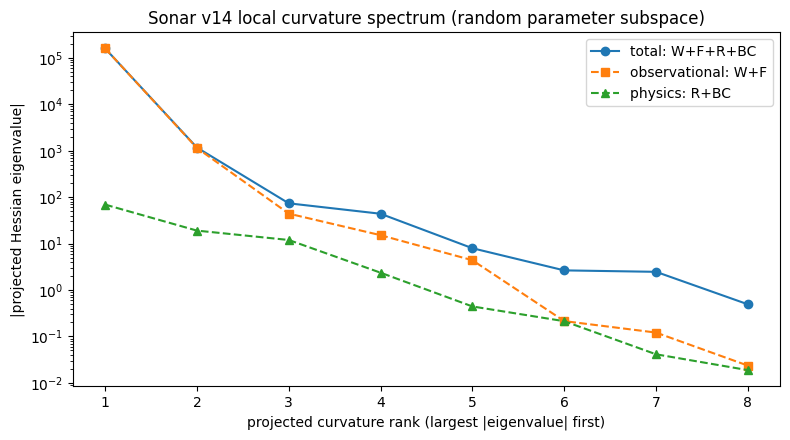

+------------------------------------------------------------------------------------------------------------------------------+
|                                Which v14 terms constrain the physics-loss sloppy directions?                                 |
+------+------------+------------+------------+------------+------------+------------+------------+----------------------------+
| rank |    k_W     |    k_F     |    k_R     |    k_BC    |   k_OBS    |   k_PHYS   |  k_TOTAL   |       local verdict        |
+------+------------+------------+------------+------------+------------+------------+------------+----------------------------+
|  1   | +1.157e+02 | +2.417e-02 | +1.880e-02 | +4.165e-05 | +1.158e+02 | +1.885e-02 | +1.158e+02 | OBS constrains PHYS-sloppy |
|  2   | +7.709e+02 | +2.519e+00 | +4.113e-02 | +2.004e-04 | +7.734e+02 | +4.133e-02 | +7.735e+02 | OBS constrains PHYS-sloppy |
|  3   | +6.330e+04 | +7.422e+00 | +2.132e-01 | +1.600e-04 | +6.331e+04 | +2.133e-01 | +6.331e+04

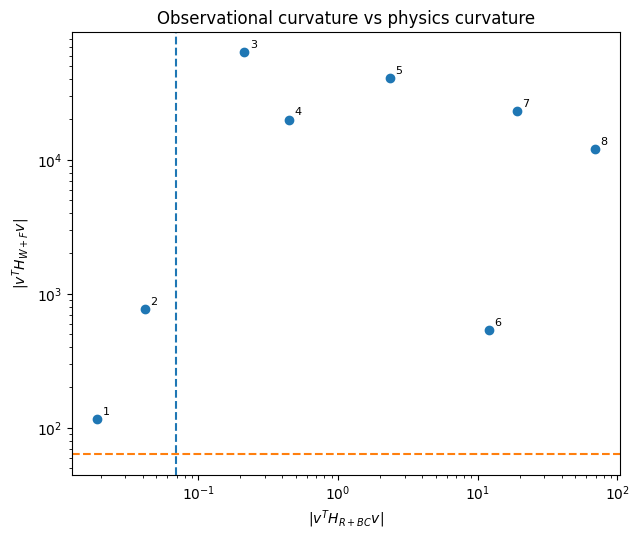

Restored and saved final network to /content/drive/MyDrive/sonar_v15_final.pt


In [83]:
v14_curvature = run_v14_native_curvature_audit(
    net,
    n_directions=8,
    rel_step=1e-4,
    seed=1400,
    sloppy_fraction=1e-3,
    save_path=FINAL_PATH,
    make_plots=True,
)

Saved pre-diagnostic network to /content/drive/MyDrive/sonar_v15_final.pt
v14 curvature audit: parameters=69, subspace=8, rel_step=3.0e-04, absolute_step=3.728e-03
+--------------------------------------------------------------+
| Sonar v14 weighted losses and gradients at the final network |
+-----------+---------------+--------------+-------------------+
|    term   | weighted loss |  |gradient|  |  cos(grad, total) |
+-----------+---------------+--------------+-------------------+
|     W     |  7.313151e-06 | 7.390603e-02 |     +0.999145     |
|     F     |  1.347037e-06 | 4.603258e-03 |     +0.488314     |
|     R     |  3.672462e-05 | 3.261447e-03 |     -0.164154     |
|     BC    |  2.600100e-06 | 1.845834e-03 |     -0.261841     |
|  OBS=W+F  |  8.660188e-06 | 7.615517e-02 |     +0.999154     |
| PHYS=R+BC |  3.932472e-05 | 3.294154e-03 |     -0.309244     |
|   TOTAL   |  4.798491e-05 | 7.507201e-02 |     +1.000000     |
+-----------+---------------+--------------+------------

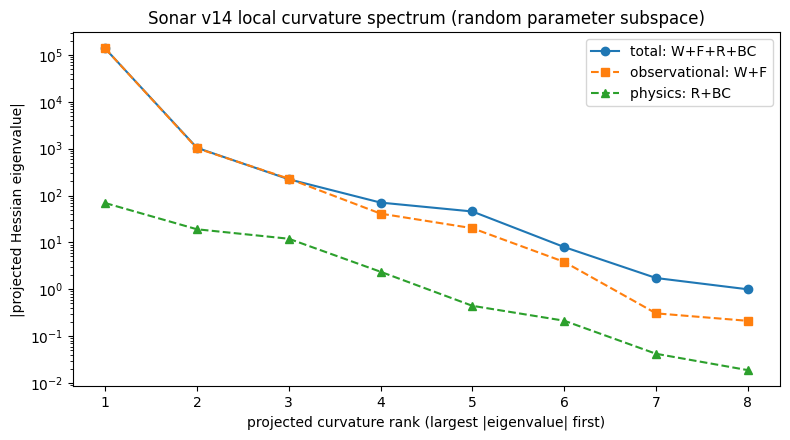

+------------------------------------------------------------------------------------------------------------------------------+
|                                Which v14 terms constrain the physics-loss sloppy directions?                                 |
+------+------------+------------+------------+------------+------------+------------+------------+----------------------------+
| rank |    k_W     |    k_F     |    k_R     |    k_BC    |   k_OBS    |   k_PHYS   |  k_TOTAL   |       local verdict        |
+------+------------+------------+------------+------------+------------+------------+------------+----------------------------+
|  1   | +2.092e+02 | +2.478e-02 | +1.879e-02 | +3.968e-05 | +2.092e+02 | +1.883e-02 | +2.092e+02 | OBS constrains PHYS-sloppy |
|  2   | +1.000e+03 | +2.595e+00 | +4.184e-02 | +2.038e-04 | +1.003e+03 | +4.205e-02 | +1.003e+03 | OBS constrains PHYS-sloppy |
|  3   | +5.223e+04 | +7.326e+00 | +2.132e-01 | +1.609e-04 | +5.224e+04 | +2.134e-01 | +5.224e+04

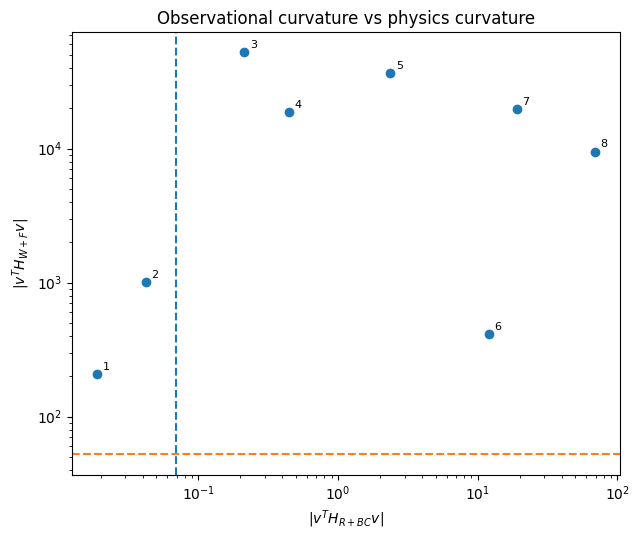

Restored and saved final network to /content/drive/MyDrive/sonar_v15_final.pt


In [84]:
v14_curvature_step_check = run_v14_native_curvature_audit(
    net,
    n_directions=8,
    rel_step=3e-4,
    seed=1400,             # same subspace
    sloppy_fraction=1e-3,
    save_path=FINAL_PATH,
    make_plots=True,
)